# Step 3 — Manual spike-amplitude filtering

Third stage of the EMG pipeline. Spike detection in Step 1 picks up everything that crosses the adaptive threshold; this step lets you keep only the large DLMn spikes by amplitude.

**Block 1:** plot spike-amplitude histograms for every bout so you can choose a `[min_amp, max_amp]` cut-off (in Volts).  
**Block 2:** apply that cut-off — set `Spike Count` to 0 for spikes outside the range, recompute the spike rate, and save the filtered CSVs into `output_csv_spikefiltered/<stim>ms/` (sorted by stimulus duration).  
**Block 3:** re-plot the filtered bouts for a final quality check and write a `bout_quality_summary.csv` (per-bout baseline vs stimulus metrics + a manual `keep` column) to help decide which bouts to drop.

**Inputs:** the `output_csv/` bout CSVs from Step 1.  
**Outputs:** `output_csv_spikefiltered/` (filtered CSVs, QC plots, quality summary).

---

# 第三步 —— 人工锋电位幅度筛选

EMG 流程的第三阶段。第一步的锋电位检测会捕捉到所有超过自适应阈值的事件；本步骤让你按幅度只保留较大的 DLMn 锋电位。

**Block 1：** 为每个片段绘制锋电位幅度直方图，以便选择一个 `[min_amp, max_amp]` 阈值（单位伏特）。  
**Block 2：** 应用该阈值——将范围之外锋电位的 `Spike Count` 置 0，重新计算发放率，并将筛选后的 CSV 按刺激时长保存到 `output_csv_spikefiltered/<刺激>ms/`。  
**Block 3：** 重新绘制筛选后的片段做最终质量检查，并写出 `bout_quality_summary.csv`（每个片段的基线对刺激指标 + 人工 `keep` 列），帮助决定剔除哪些片段。

**输入：** 来自第一步的 `output_csv/` 片段 CSV。  
**输出：** `output_csv_spikefiltered/`（筛选后的 CSV、质量检查图、质量汇总表）。

## Block 1: Spike-amplitude histograms → pick the cut-off

Defines `plot_all_bouts_in_folder`, which reads every bout CSV in a folder and plots a grid of per-bout spike-amplitude histograms plus one pooled summary histogram (with mean / median / std). Use these distributions to manually choose the `[min_amp, max_amp]` threshold that isolates the DLMn spikes.

**Block 1：锋电位幅度直方图 → 选取阈值**

定义 `plot_all_bouts_in_folder`，它读取某文件夹中的每个片段 CSV，绘制逐片段锋电位幅度直方图的网格图，以及一张汇总的总体直方图（含均值／中位数／标准差）。根据这些分布人工选择能分离出 DLMn 锋电位的 `[min_amp, max_amp]` 阈值。

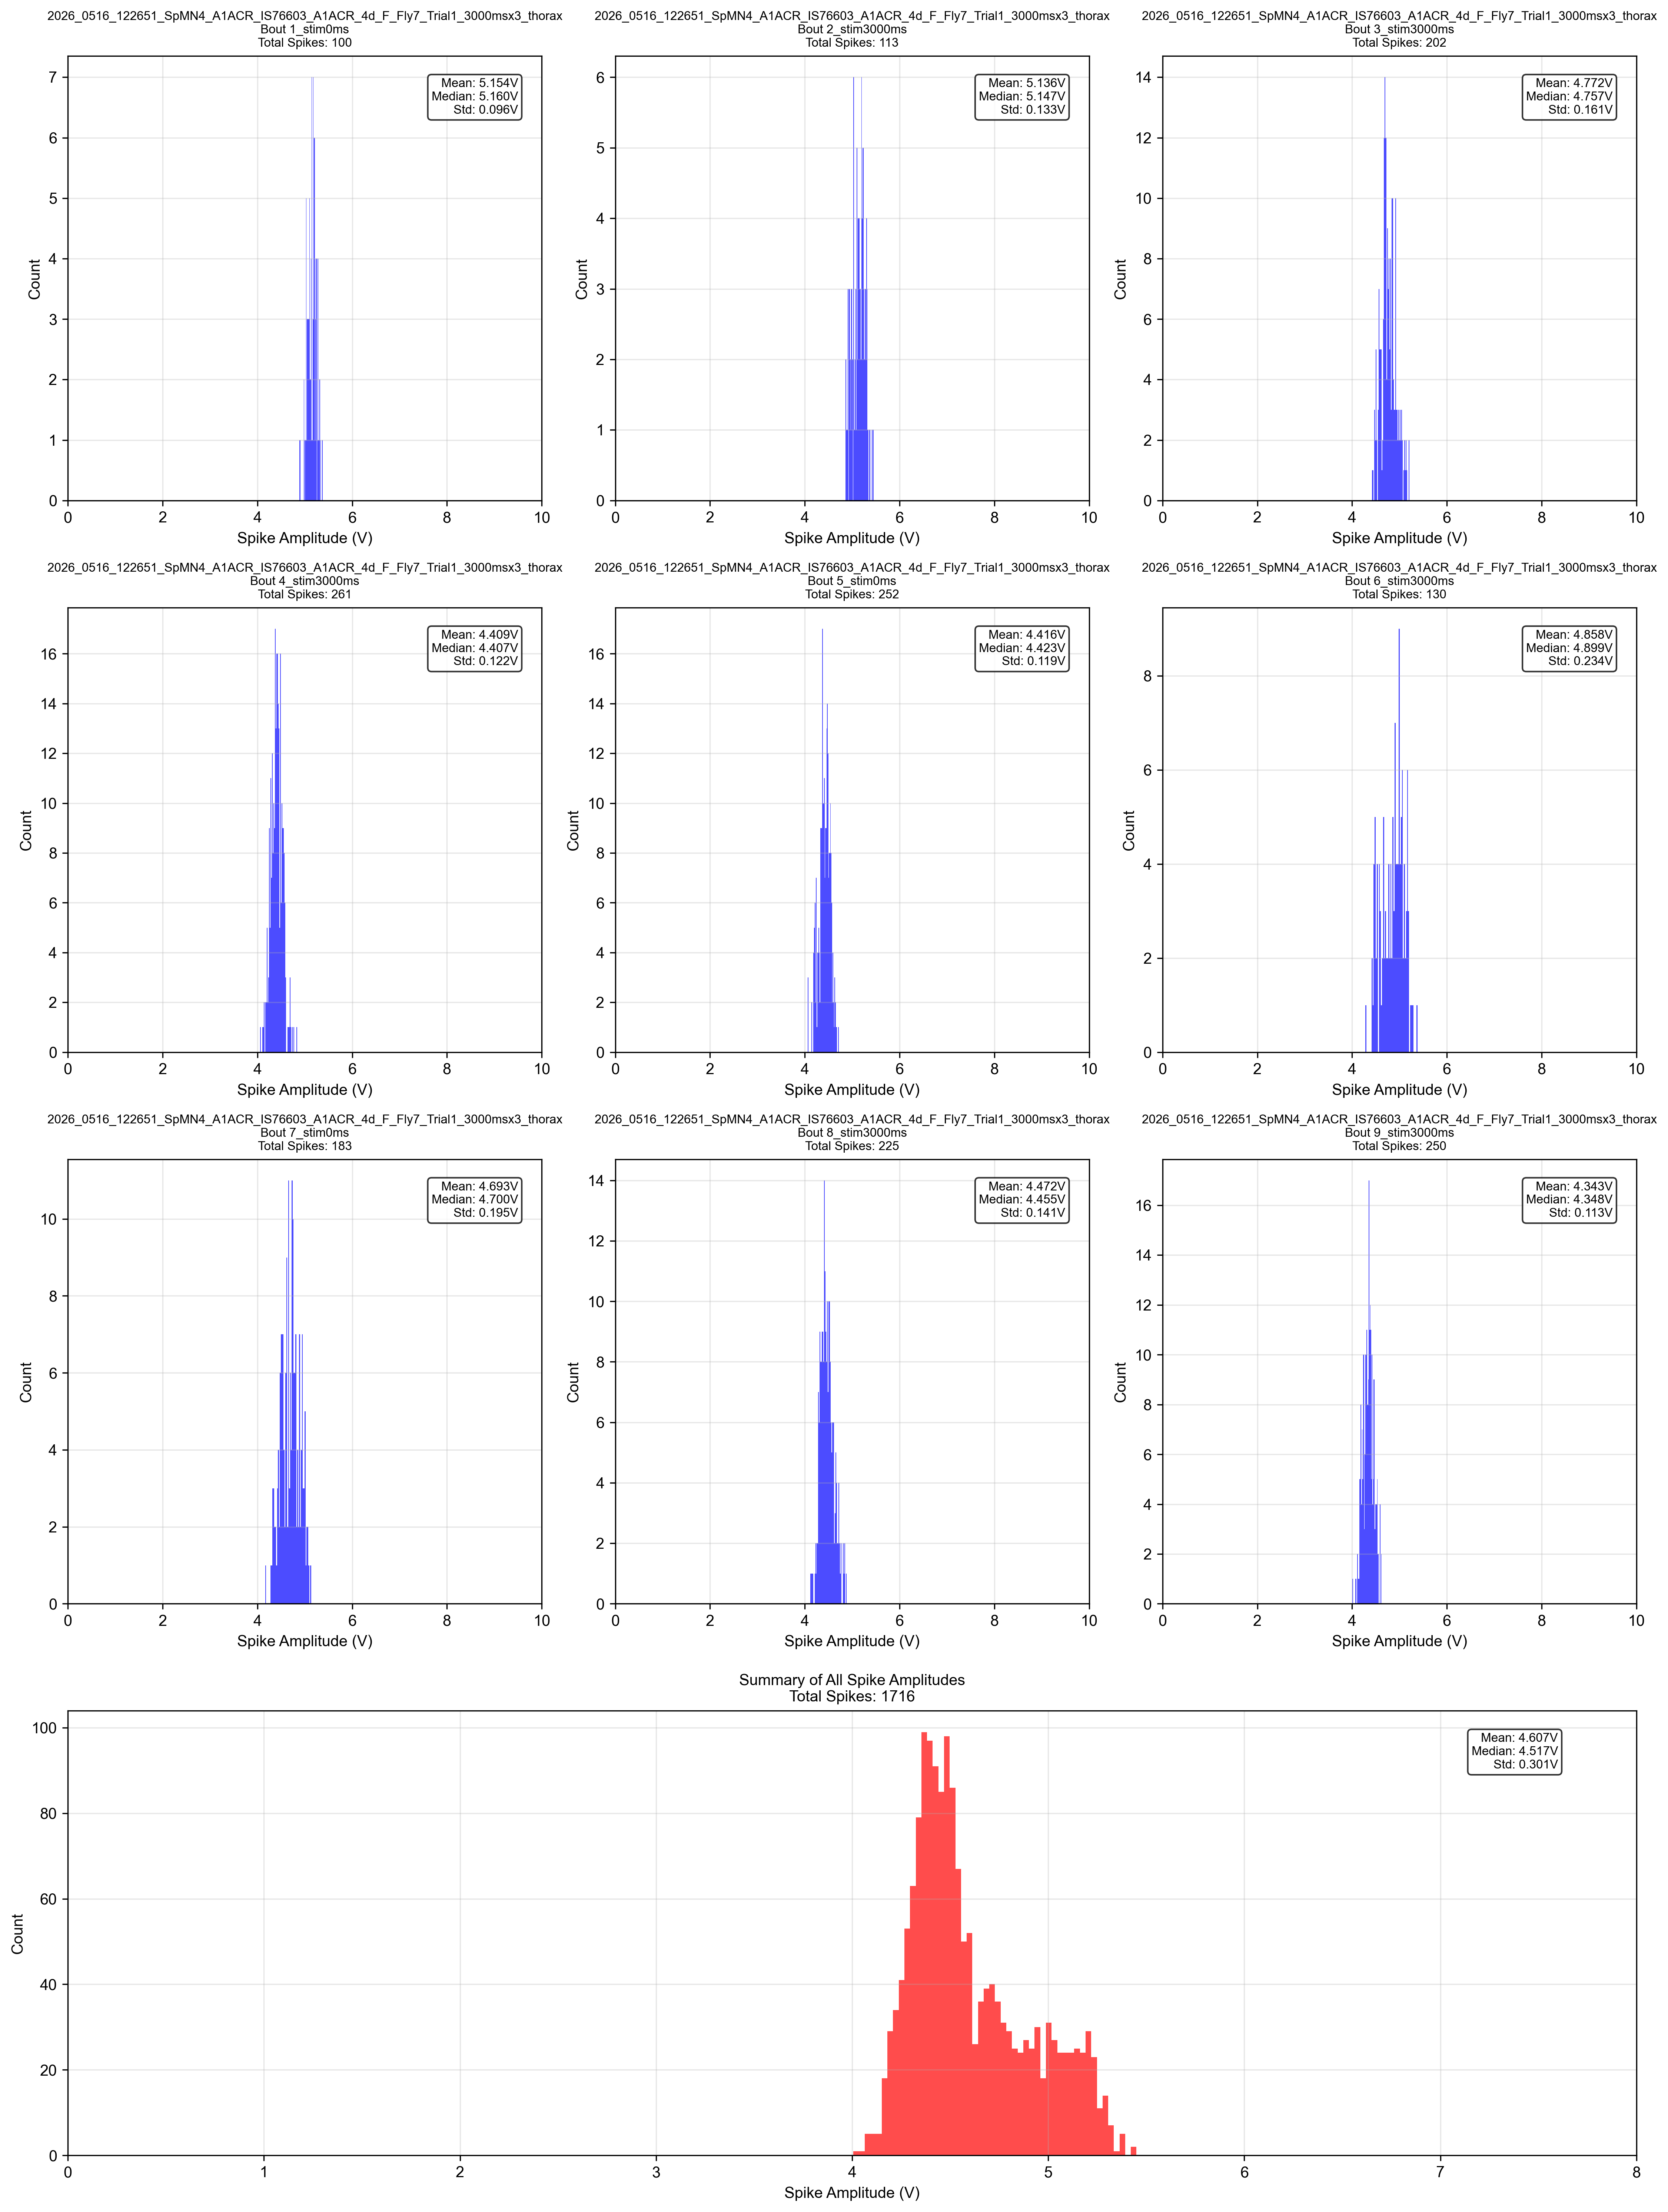

In [21]:
# Step 1, check the spike amplitude histogram, and select (manually) the cut-off threshold for DLMn spikes.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from natsort import natsorted

%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'
set_plot_style()

def plot_all_bouts_in_folder(base_folder_path, bins=50):
    """
    Plots histograms of spike amplitudes for all CSV files in the given folder.
    
    Parameters:
    - base_folder_path (str): Path to the folder containing CSV files with spike data.
    - bins (int): Number of bins for the histograms (default 50).
    
    This function generates individual histograms for each CSV file and a summary histogram
    showing the distribution of spike amplitudes across all files.
    """
    csv_files = []
    all_spike_amplitudes = []
    
    for root, dirs, files in os.walk(base_folder_path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    
    csv_files = natsorted(csv_files)
    n_files = len(csv_files)
    n_cols = 3
    n_rows = (n_files + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(15, 5*(n_rows + 1)))
    gs = plt.GridSpec(n_rows + 1, n_cols, figure=fig)
    
    # Individual histograms
    for idx, csv_file_path in enumerate(csv_files):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        data = pd.read_csv(csv_file_path)
        spike_amplitudes = data['Spike Amplitude'][data['Spike Count'] == 1]
        all_spike_amplitudes.extend(spike_amplitudes)
        
        ax.hist(spike_amplitudes, bins=bins, color='blue', alpha=0.7)
        ax.set_xlim(0, 10)
        
        if len(spike_amplitudes) > 0:
            mean_amp = np.mean(spike_amplitudes)
            median_amp = np.median(spike_amplitudes)
            std_amp = np.std(spike_amplitudes)
        else:
            mean_amp = median_amp = std_amp = 0
        
        ax.set_xlabel('Spike Amplitude (V)')
        ax.set_ylabel('Count')
        
        csv_filename = os.path.basename(csv_file_path)
        trial_info = csv_filename.split('_bout')[0]
        bout_info = csv_filename.split('_bout')[1].split('.csv')[0]
        
        ax.set_title(f'{trial_info}\nBout {bout_info}\nTotal Spikes: {len(spike_amplitudes)}',
                    fontsize=8)
        
        stats_text = f'Mean: {mean_amp:.3f}V\nMedian: {median_amp:.3f}V\nStd: {std_amp:.3f}V'
        ax.text(0.95, 0.95, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplots
    for idx in range(len(csv_files), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        fig.delaxes(fig.add_subplot(gs[row, col]))
    
    # Summary histogram
    ax_summary = fig.add_subplot(gs[-1, :])
    ax_summary.hist(all_spike_amplitudes, bins=bins, color='red', alpha=0.7)
    ax_summary.set_xlim(0, 8)
    ax_summary.set_xlabel('Spike Amplitude (V)')
    ax_summary.set_ylabel('Count')
    ax_summary.set_title('Summary of All Spike Amplitudes\n'
                        f'Total Spikes: {len(all_spike_amplitudes)}',
                        fontsize=10)
    
    mean_all = np.mean(all_spike_amplitudes)
    median_all = np.median(all_spike_amplitudes)
    std_all = np.std(all_spike_amplitudes)
    stats_text = f'Mean: {mean_all:.3f}V\nMedian: {median_all:.3f}V\nStd: {std_all:.3f}V'
    ax_summary.text(0.95, 0.95, stats_text,
                   transform=ax_summary.transAxes,
                   verticalalignment='top',
                   horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                   fontsize=8)
    ax_summary.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage, this is the output_csv folder.
folder_path = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/8_SpMN4_A1ACR/260516_SpMN4_A1ACR_EMG_Fly7/output_csv'
plot_all_bouts_in_folder(folder_path)

## Block 2: Apply the cut-off and save filtered CSVs

Defines `process_spikefiltered_csv` / `main`: for each bout CSV, spikes whose `Spike Amplitude` falls outside `[min_amp, max_amp]` have their `Spike Count` zeroed, the `Spike Rate` is recomputed, and the file is saved into a subfolder of `output_csv_spikefiltered/` named by its stimulus duration. Edit `min_amp` / `max_amp` to match the threshold chosen in Block 1.

**Block 2：应用阈值并保存筛选后的 CSV**

定义 `process_spikefiltered_csv` / `main`：对每个片段 CSV，将 `Spike Amplitude` 落在 `[min_amp, max_amp]` 之外的锋电位的 `Spike Count` 置 0，重新计算 `Spike Rate`，并把文件保存到 `output_csv_spikefiltered/` 下按刺激时长命名的子文件夹中。请将 `min_amp` / `max_amp` 改为 Block 1 中选定的阈值。

In [22]:
# Step 2: Filter the spikes and save as csv files, in different subfolders sorted by stimulus length.

import pandas as pd
import numpy as np
import os
import re
from pathlib import Path
from tqdm import tqdm
%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'

def process_spikefiltered_csv(file_path, output_dir, amp_range, sampling_rate = 20000):
    """
    Filters spikes based on amplitude range and saves the filtered CSV.
    
    Parameters:
    - file_path (str): Path to the input CSV file.
    - output_dir (str): Directory to save the filtered CSV.
    - amp_range (tuple): (min_amp, max_amp) for filtering spike amplitudes.
    - sampling_rate (int): Sampling rate for calculating spike rate (default 20000).
    
    This function sets spike count to 0 for spikes outside the amplitude range,
    calculates spike rate, and saves the file in a subdirectory based on stimulus time.
    """
    df = pd.read_csv(file_path)
    mask = (df['Spike Count'] == 1)
    outside_range = (df['Spike Amplitude'] < amp_range[0]) | (df['Spike Amplitude'] > amp_range[1])
    df.loc[mask & outside_range, 'Spike Count'] = 0
    df['Spike Rate'] = calculate_spike_rate(df['Spike Count'].values, sampling_rate)
    
    stim_match = re.search(r'stim(\d+)ms', str(file_path))
    if stim_match:
        stim_time = f"{stim_match.group(1)}ms"
        output_subdir = Path(output_dir) / stim_time
        output_subdir.mkdir(exist_ok=True)
        output_path = output_subdir / Path(file_path).name
        df.to_csv(output_path, index=False)

def main():
    """
    Main function to process all CSV files in the input path, filter spikes based on amplitude,
    and save filtered files to output_dir organized by stimulus length.
    """
    min_amp = 1
    max_amp = 6
    # input path should be the output_csv folder.
    input_path = Path('/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/8_SpMN4_A1ACR/260516_SpMN4_A1ACR_EMG_Fly7/output_csv')
    output_dir = input_path.parent / 'output_csv_spikefiltered'
    output_dir.mkdir(exist_ok=True)
    print("Input path exists:", input_path.exists())
    print("Number of CSV files:", len(list(input_path.glob('*.csv'))))
    print("Example entries in folder:")
    for p in list(input_path.iterdir())[:10]:
        print("  ", p.name)
    
    files = list(input_path.glob('*.csv'))
    for file_path in tqdm(files, desc="Processing files"):
        process_spikefiltered_csv(file_path, output_dir, (min_amp, max_amp))

if __name__ == "__main__":
    main()

Input path exists: True
Number of CSV files: 9
Example entries in folder:
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout8_stim3000ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout9_stim3000ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout6_stim3000ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout4_stim3000ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout3_stim3000ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout5_stim0ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout2_stim3000ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout7_stim0ms.csv
   2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_F_Fly7_Trial1_3000msx3_thorax_bout1_stim0ms.csv


Processing files: 100%|██████████| 9/9 [00:18<00:00,  2.06s/it]


## Block 3: Quality-check the filtered bouts

Defines `plot_filtered_data`, which walks each stimulus-duration subfolder of `output_csv_spikefiltered/` and regenerates a `plot_single_bout` figure for every filtered CSV into an `output_plots/` subfolder, so you can spot any bouts that still need to be excluded manually.

**Block 3：对筛选后的片段做质量检查**

定义 `plot_filtered_data`，它遍历 `output_csv_spikefiltered/` 下各刺激时长子文件夹，为每个筛选后的 CSV 在 `output_plots/` 子文件夹中重新生成 `plot_single_bout` 图，方便你发现仍需人工剔除的片段。

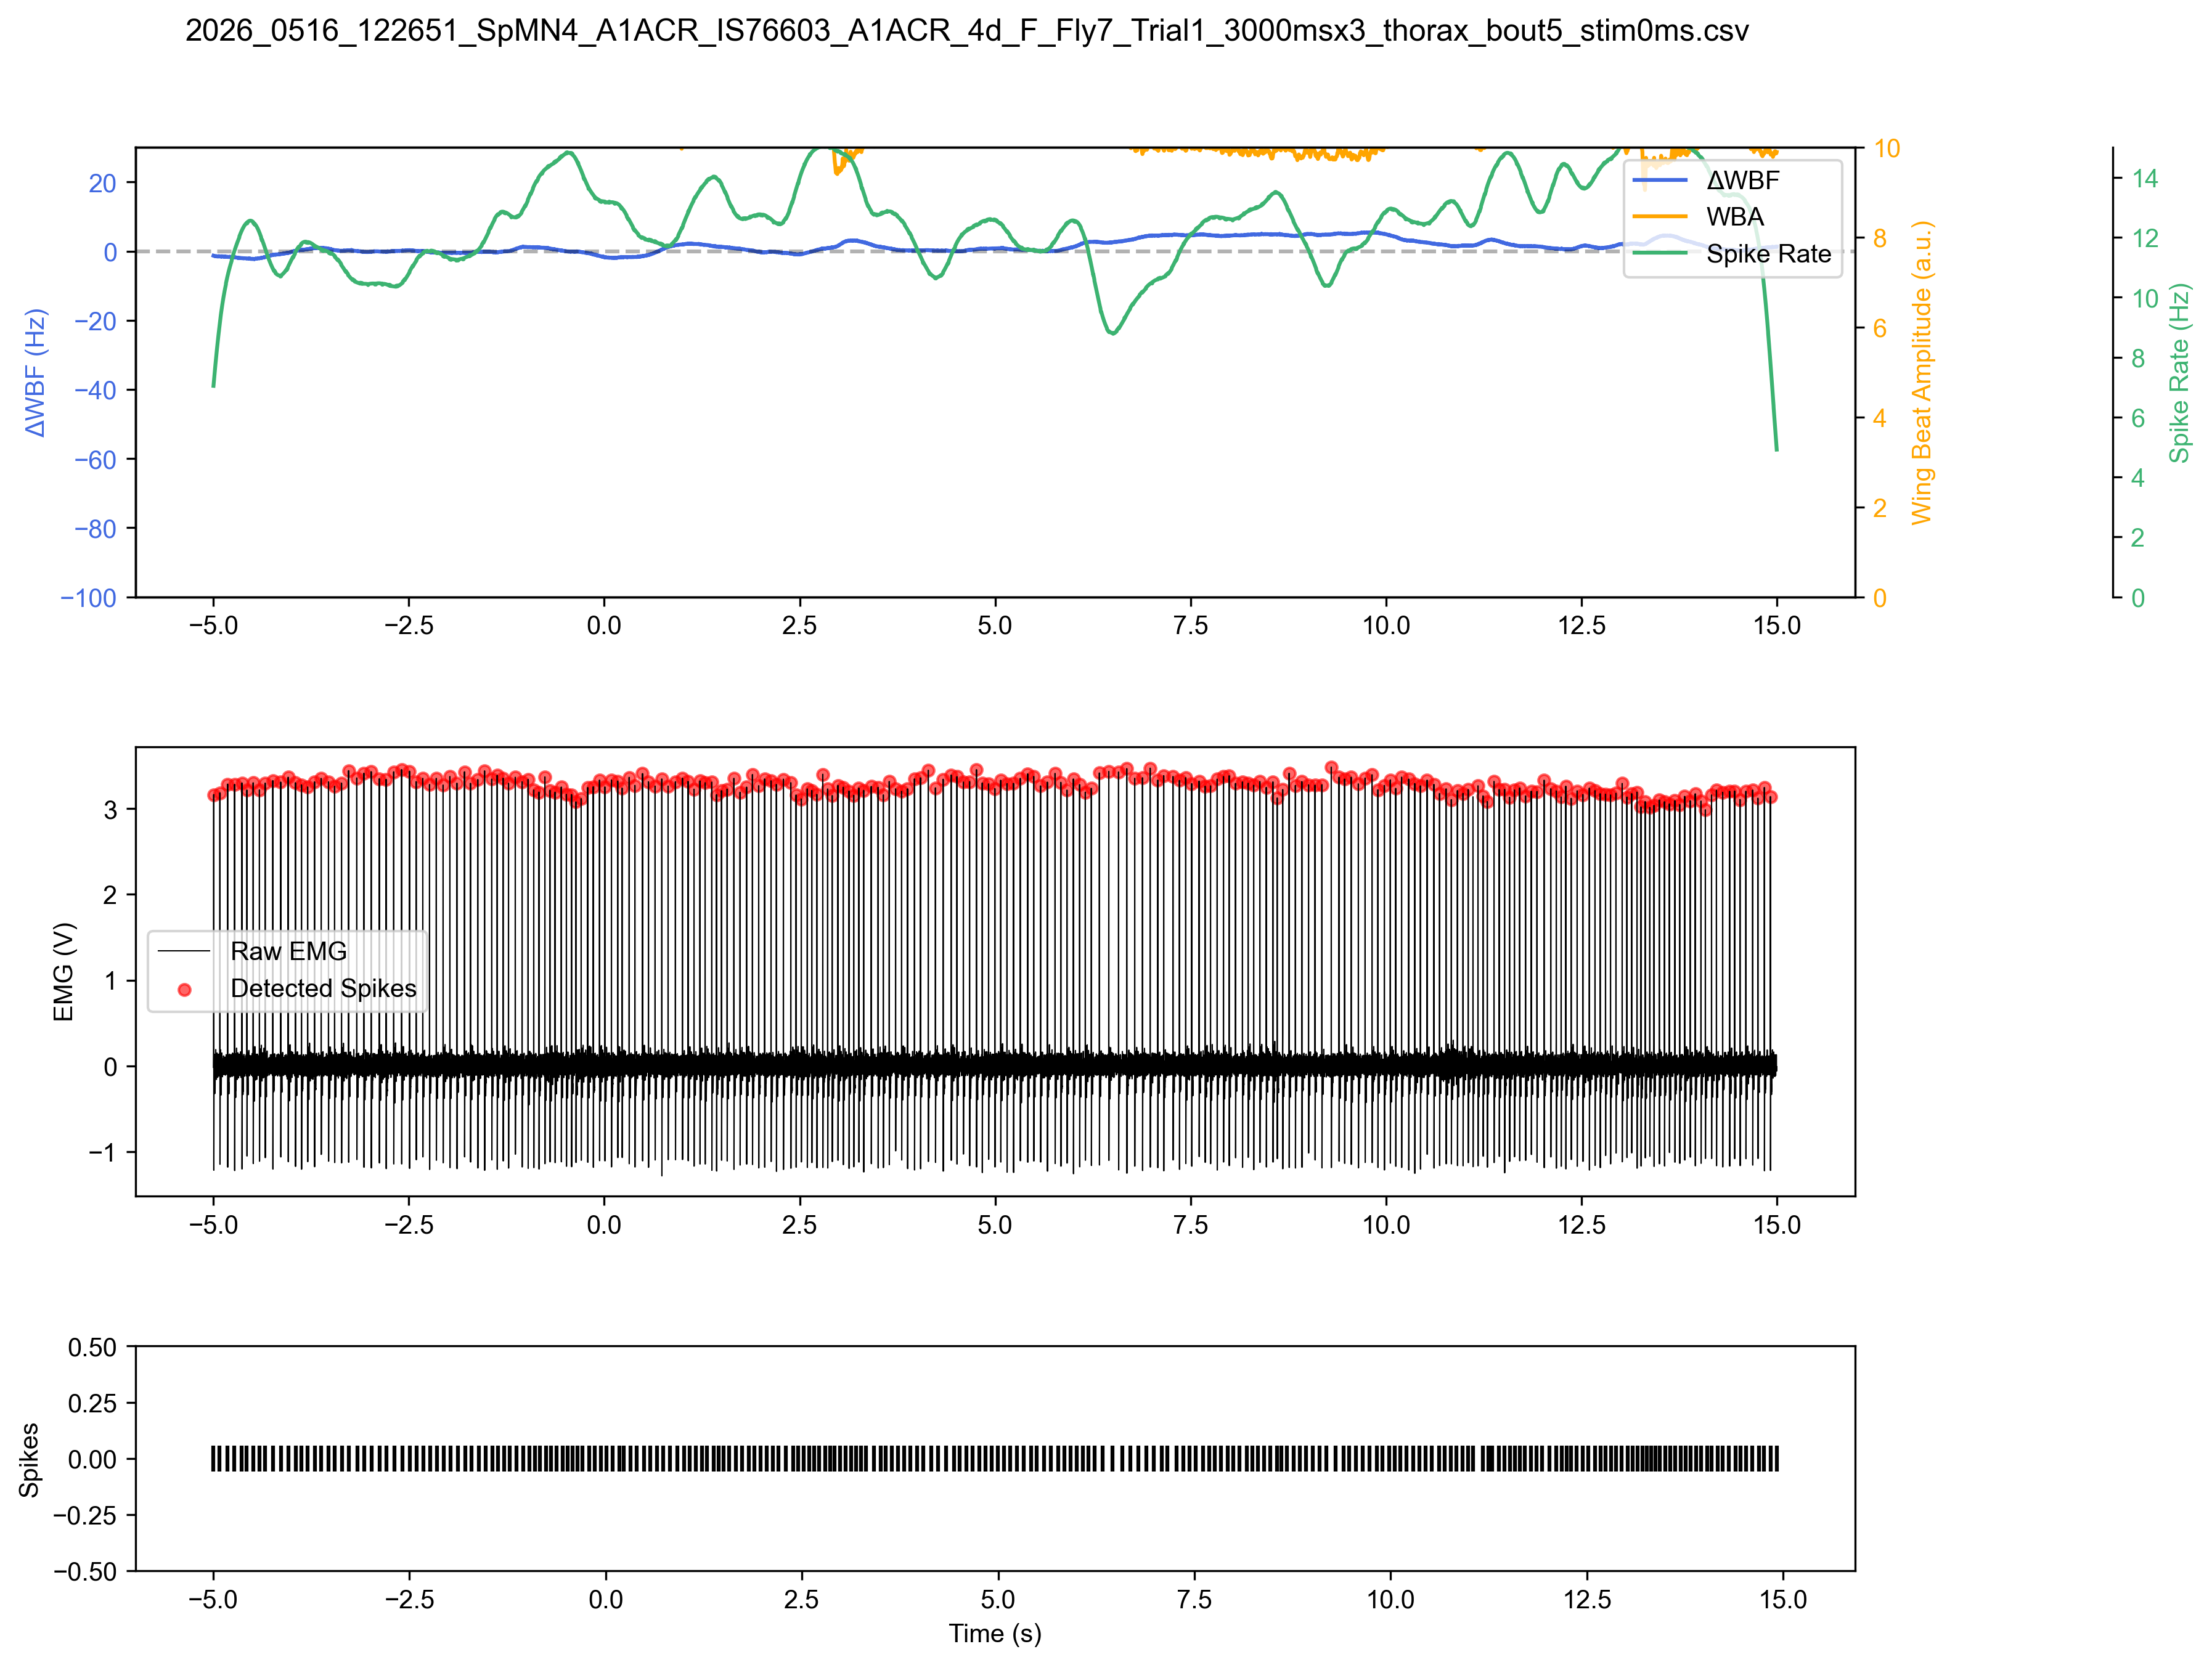

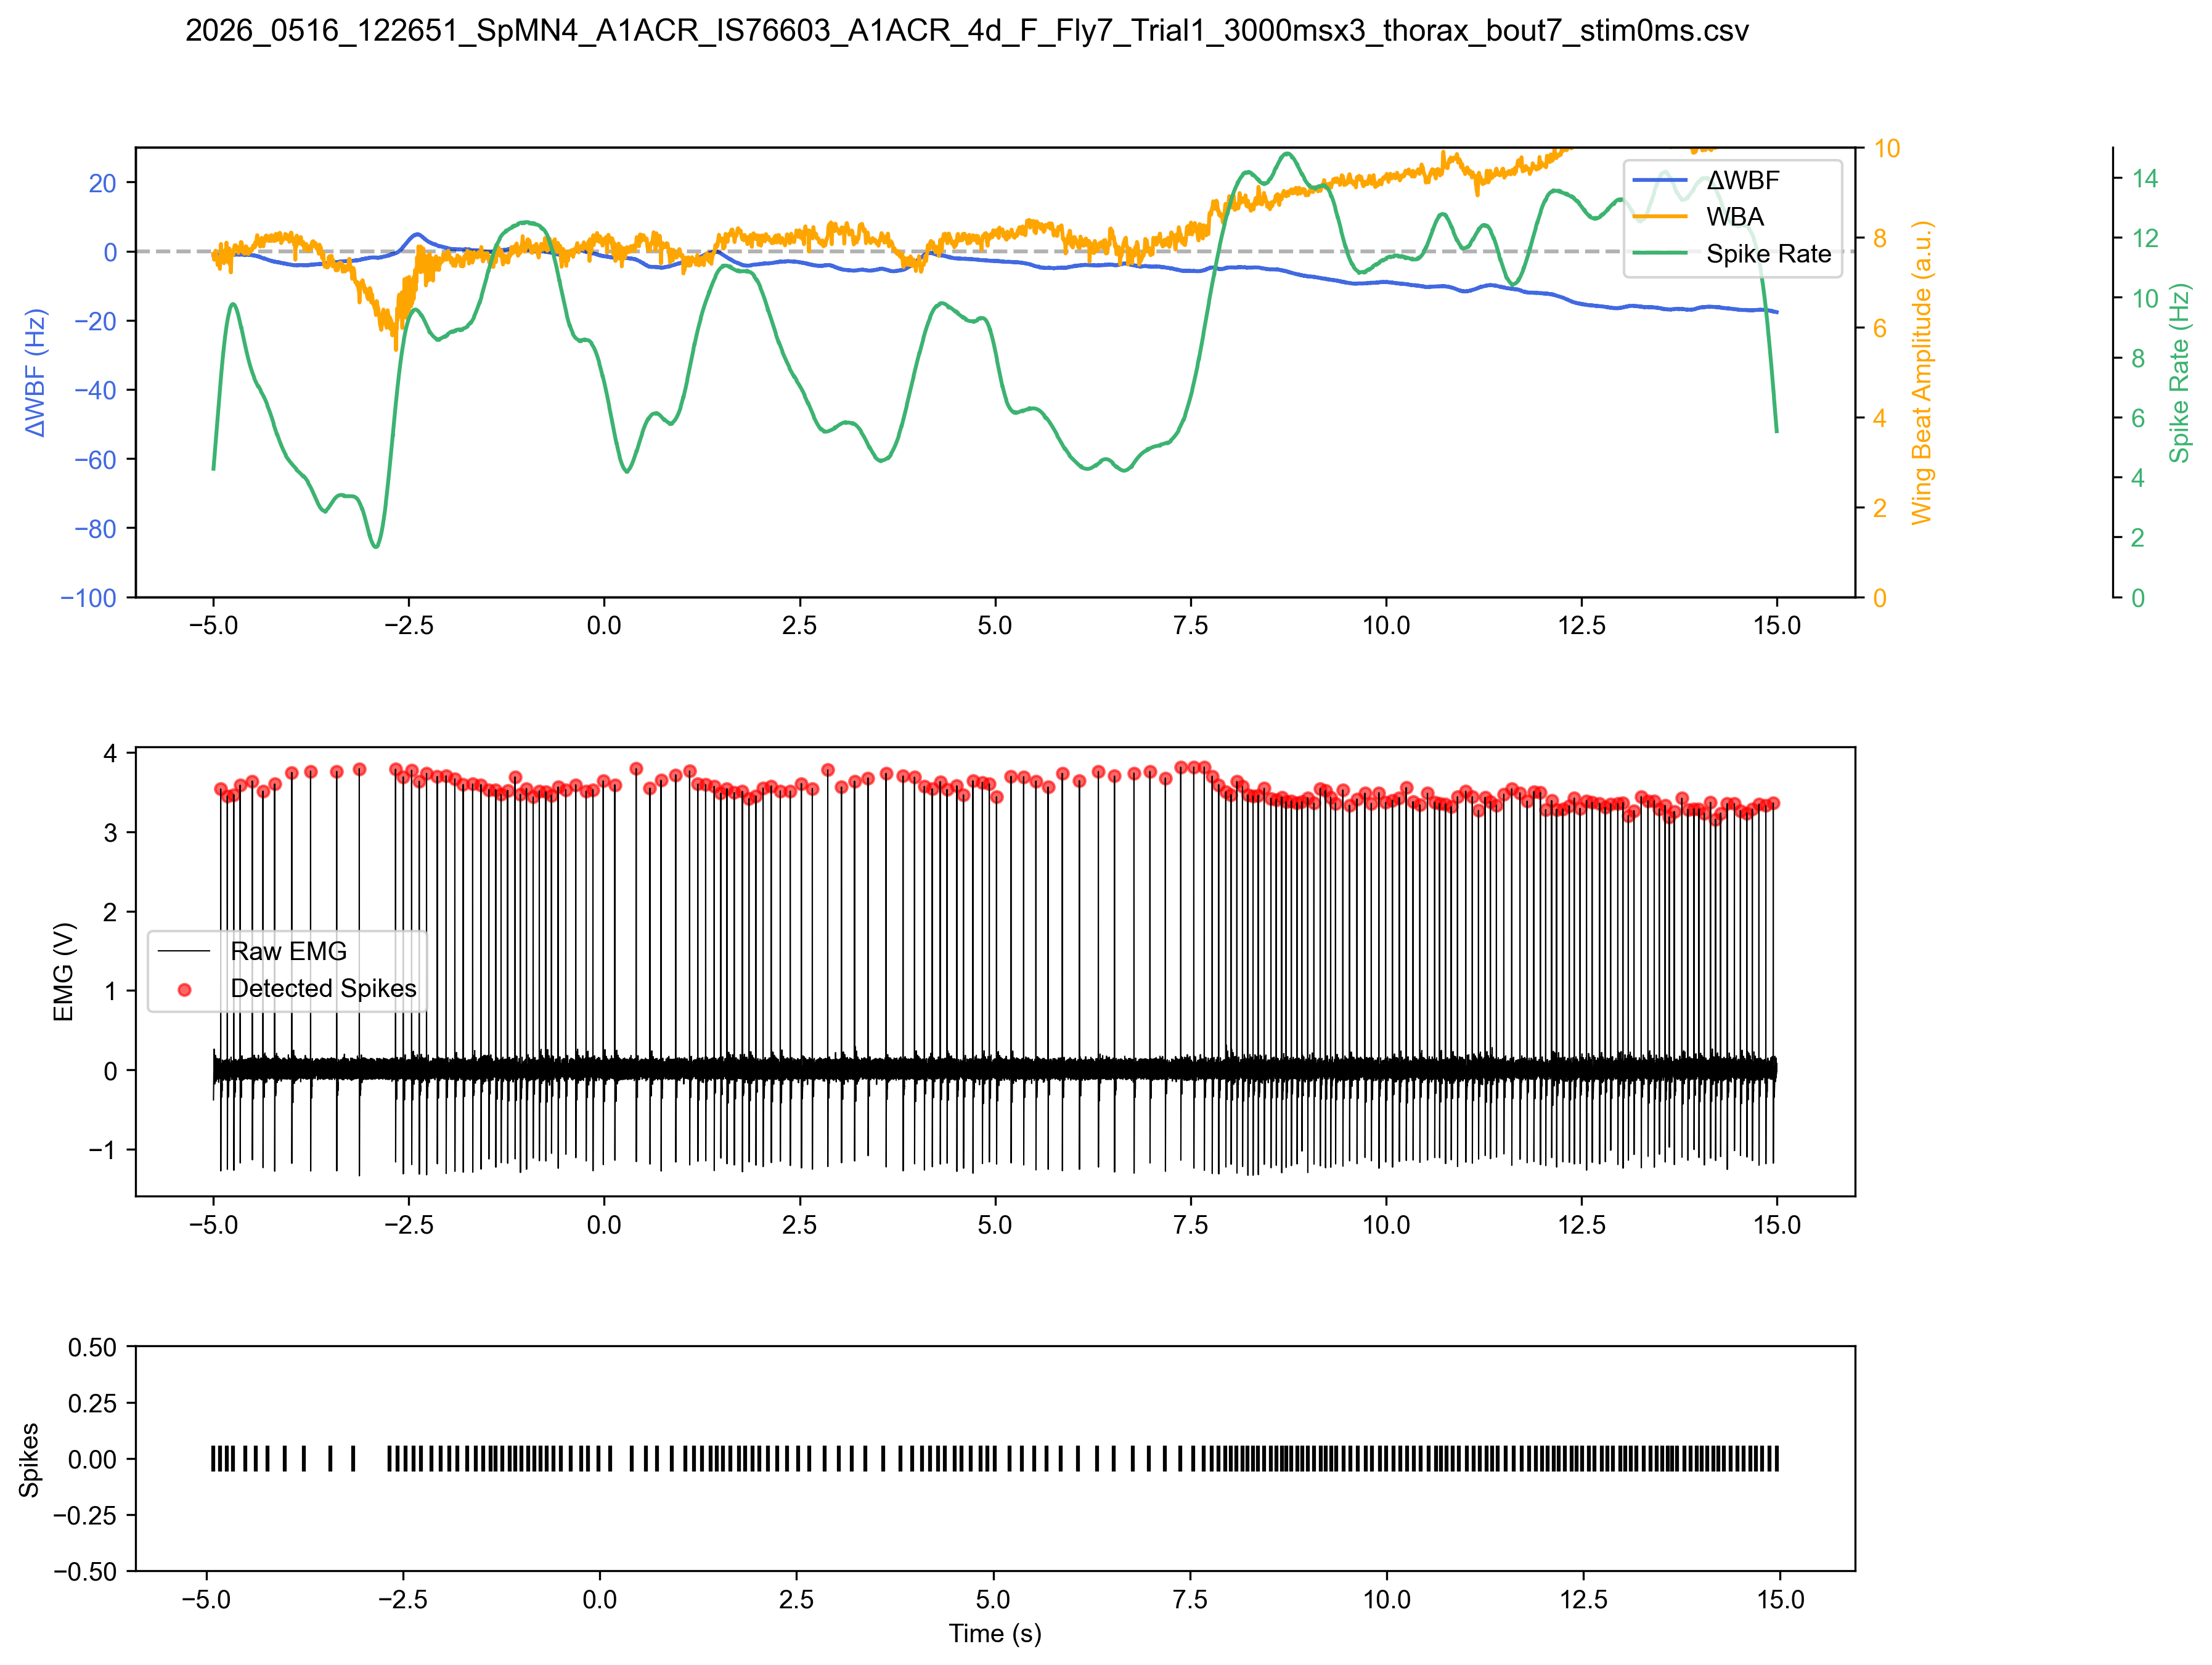

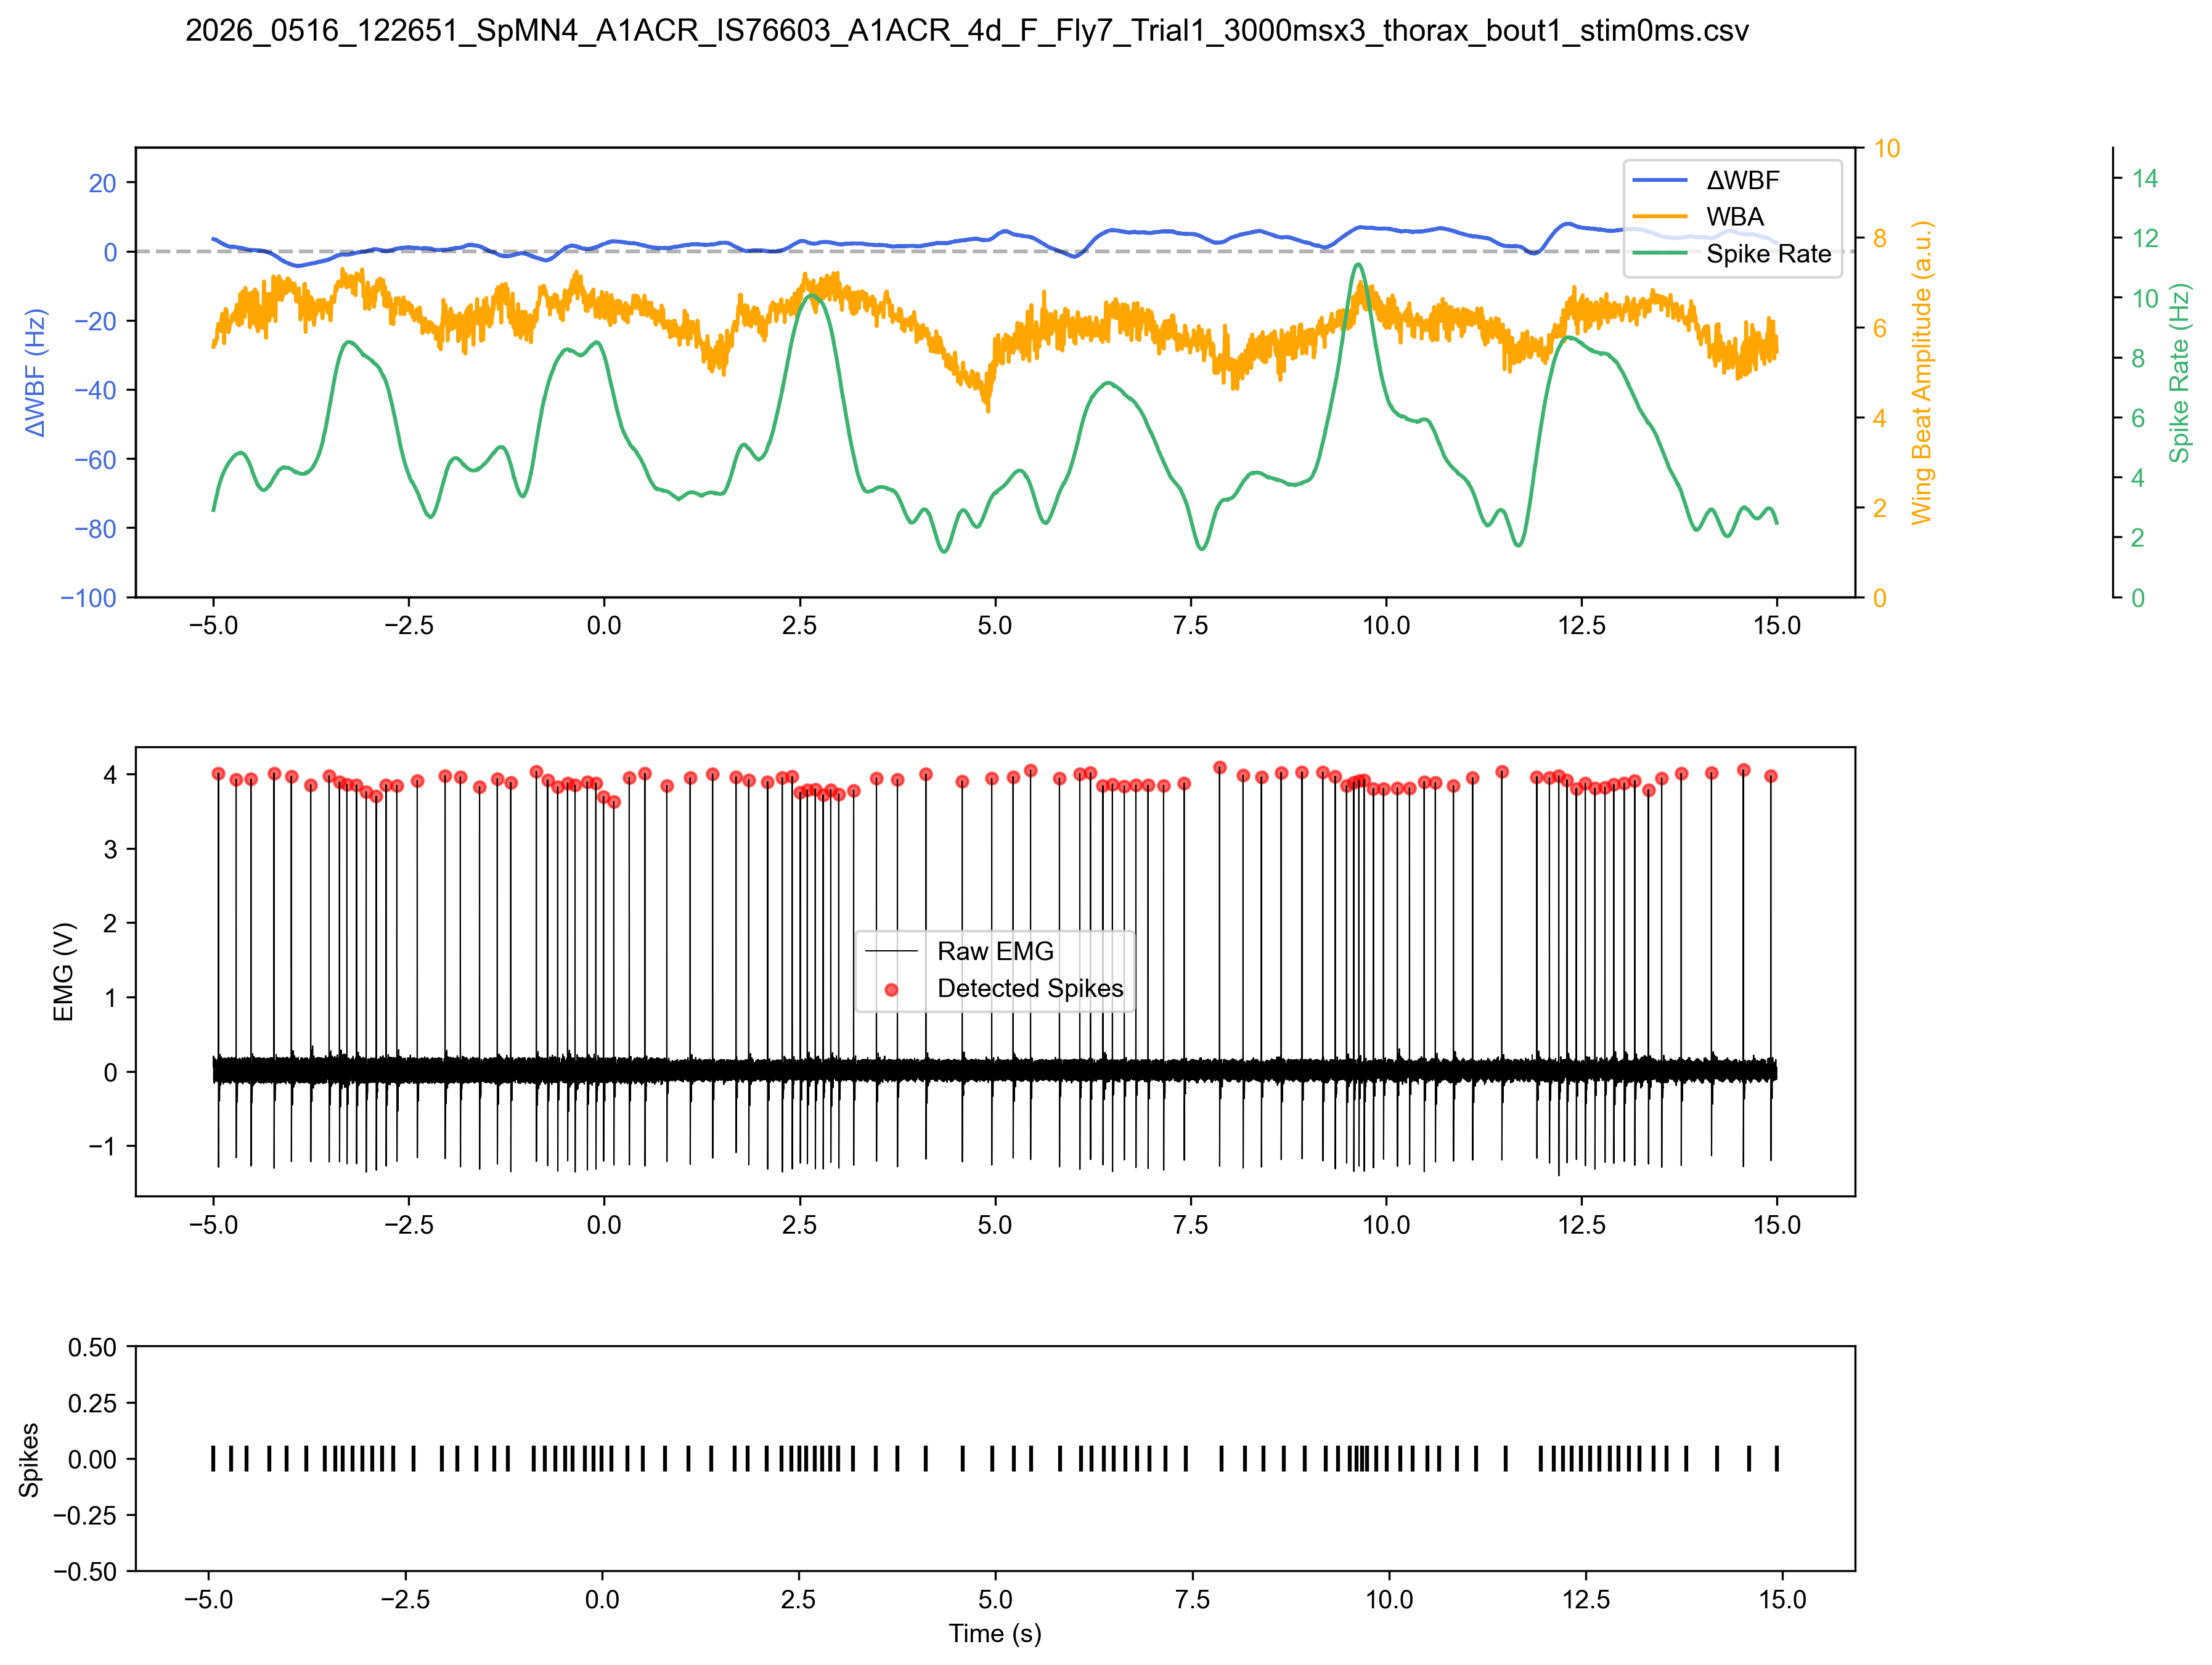

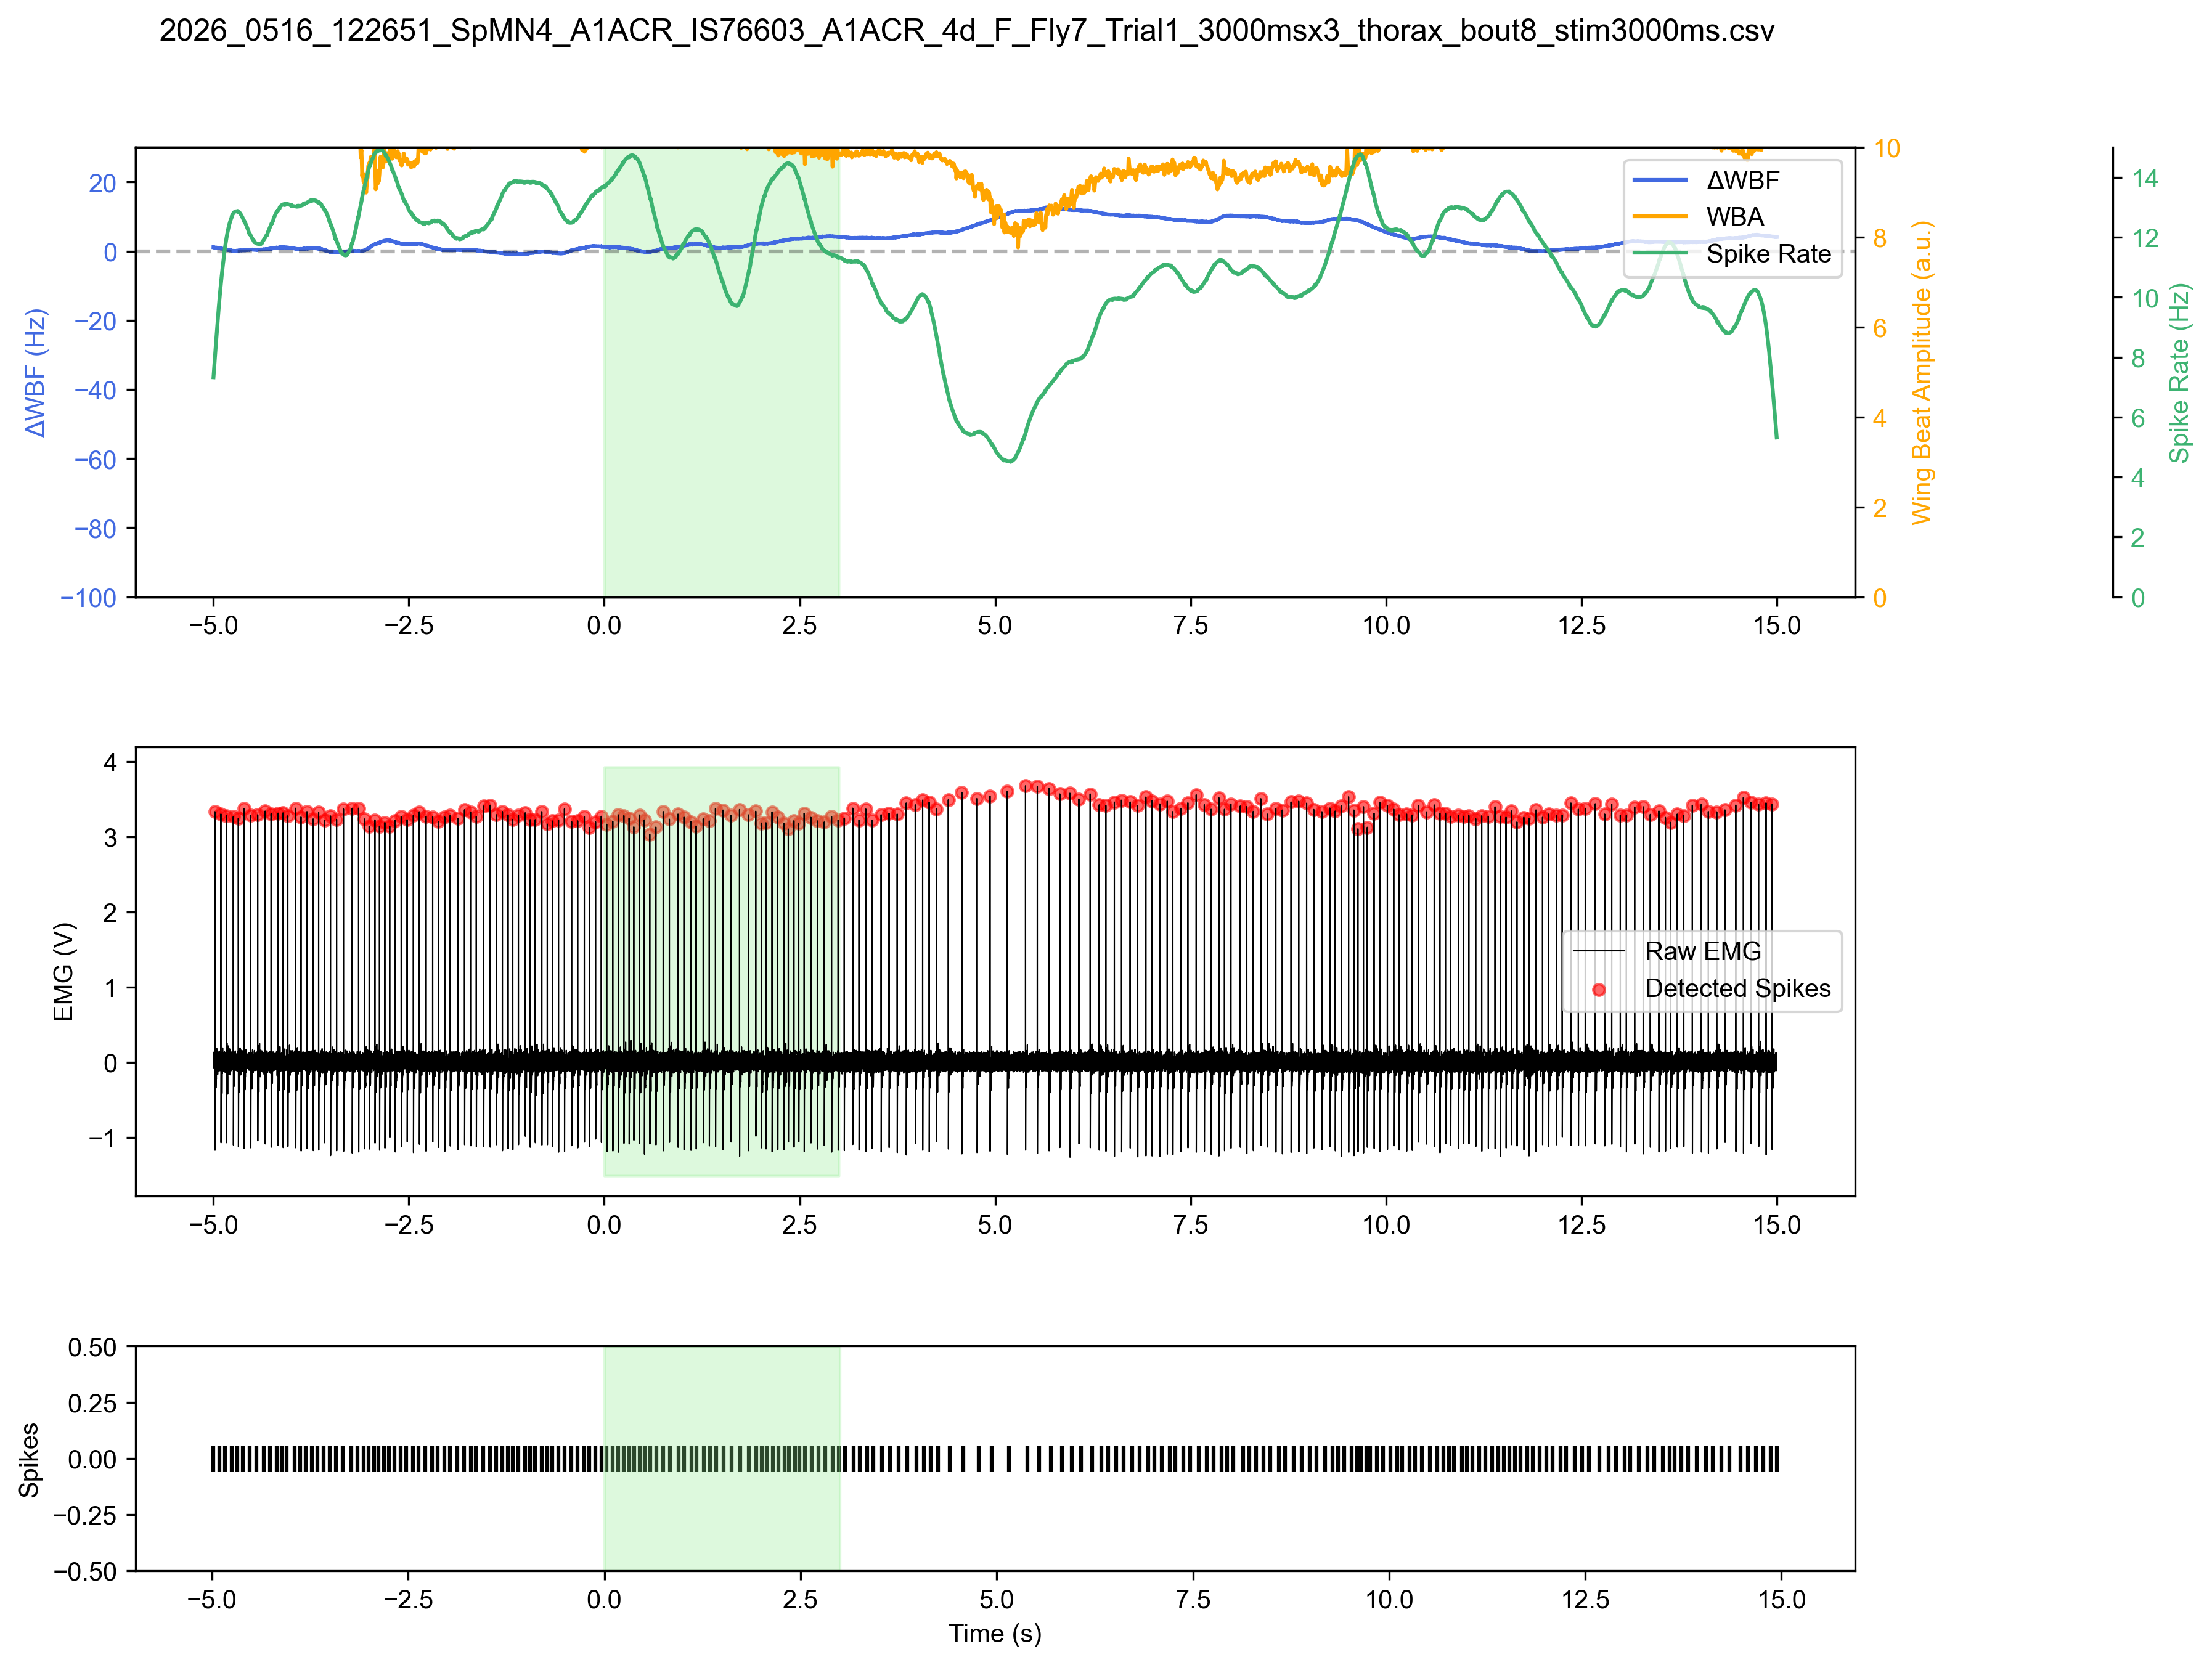

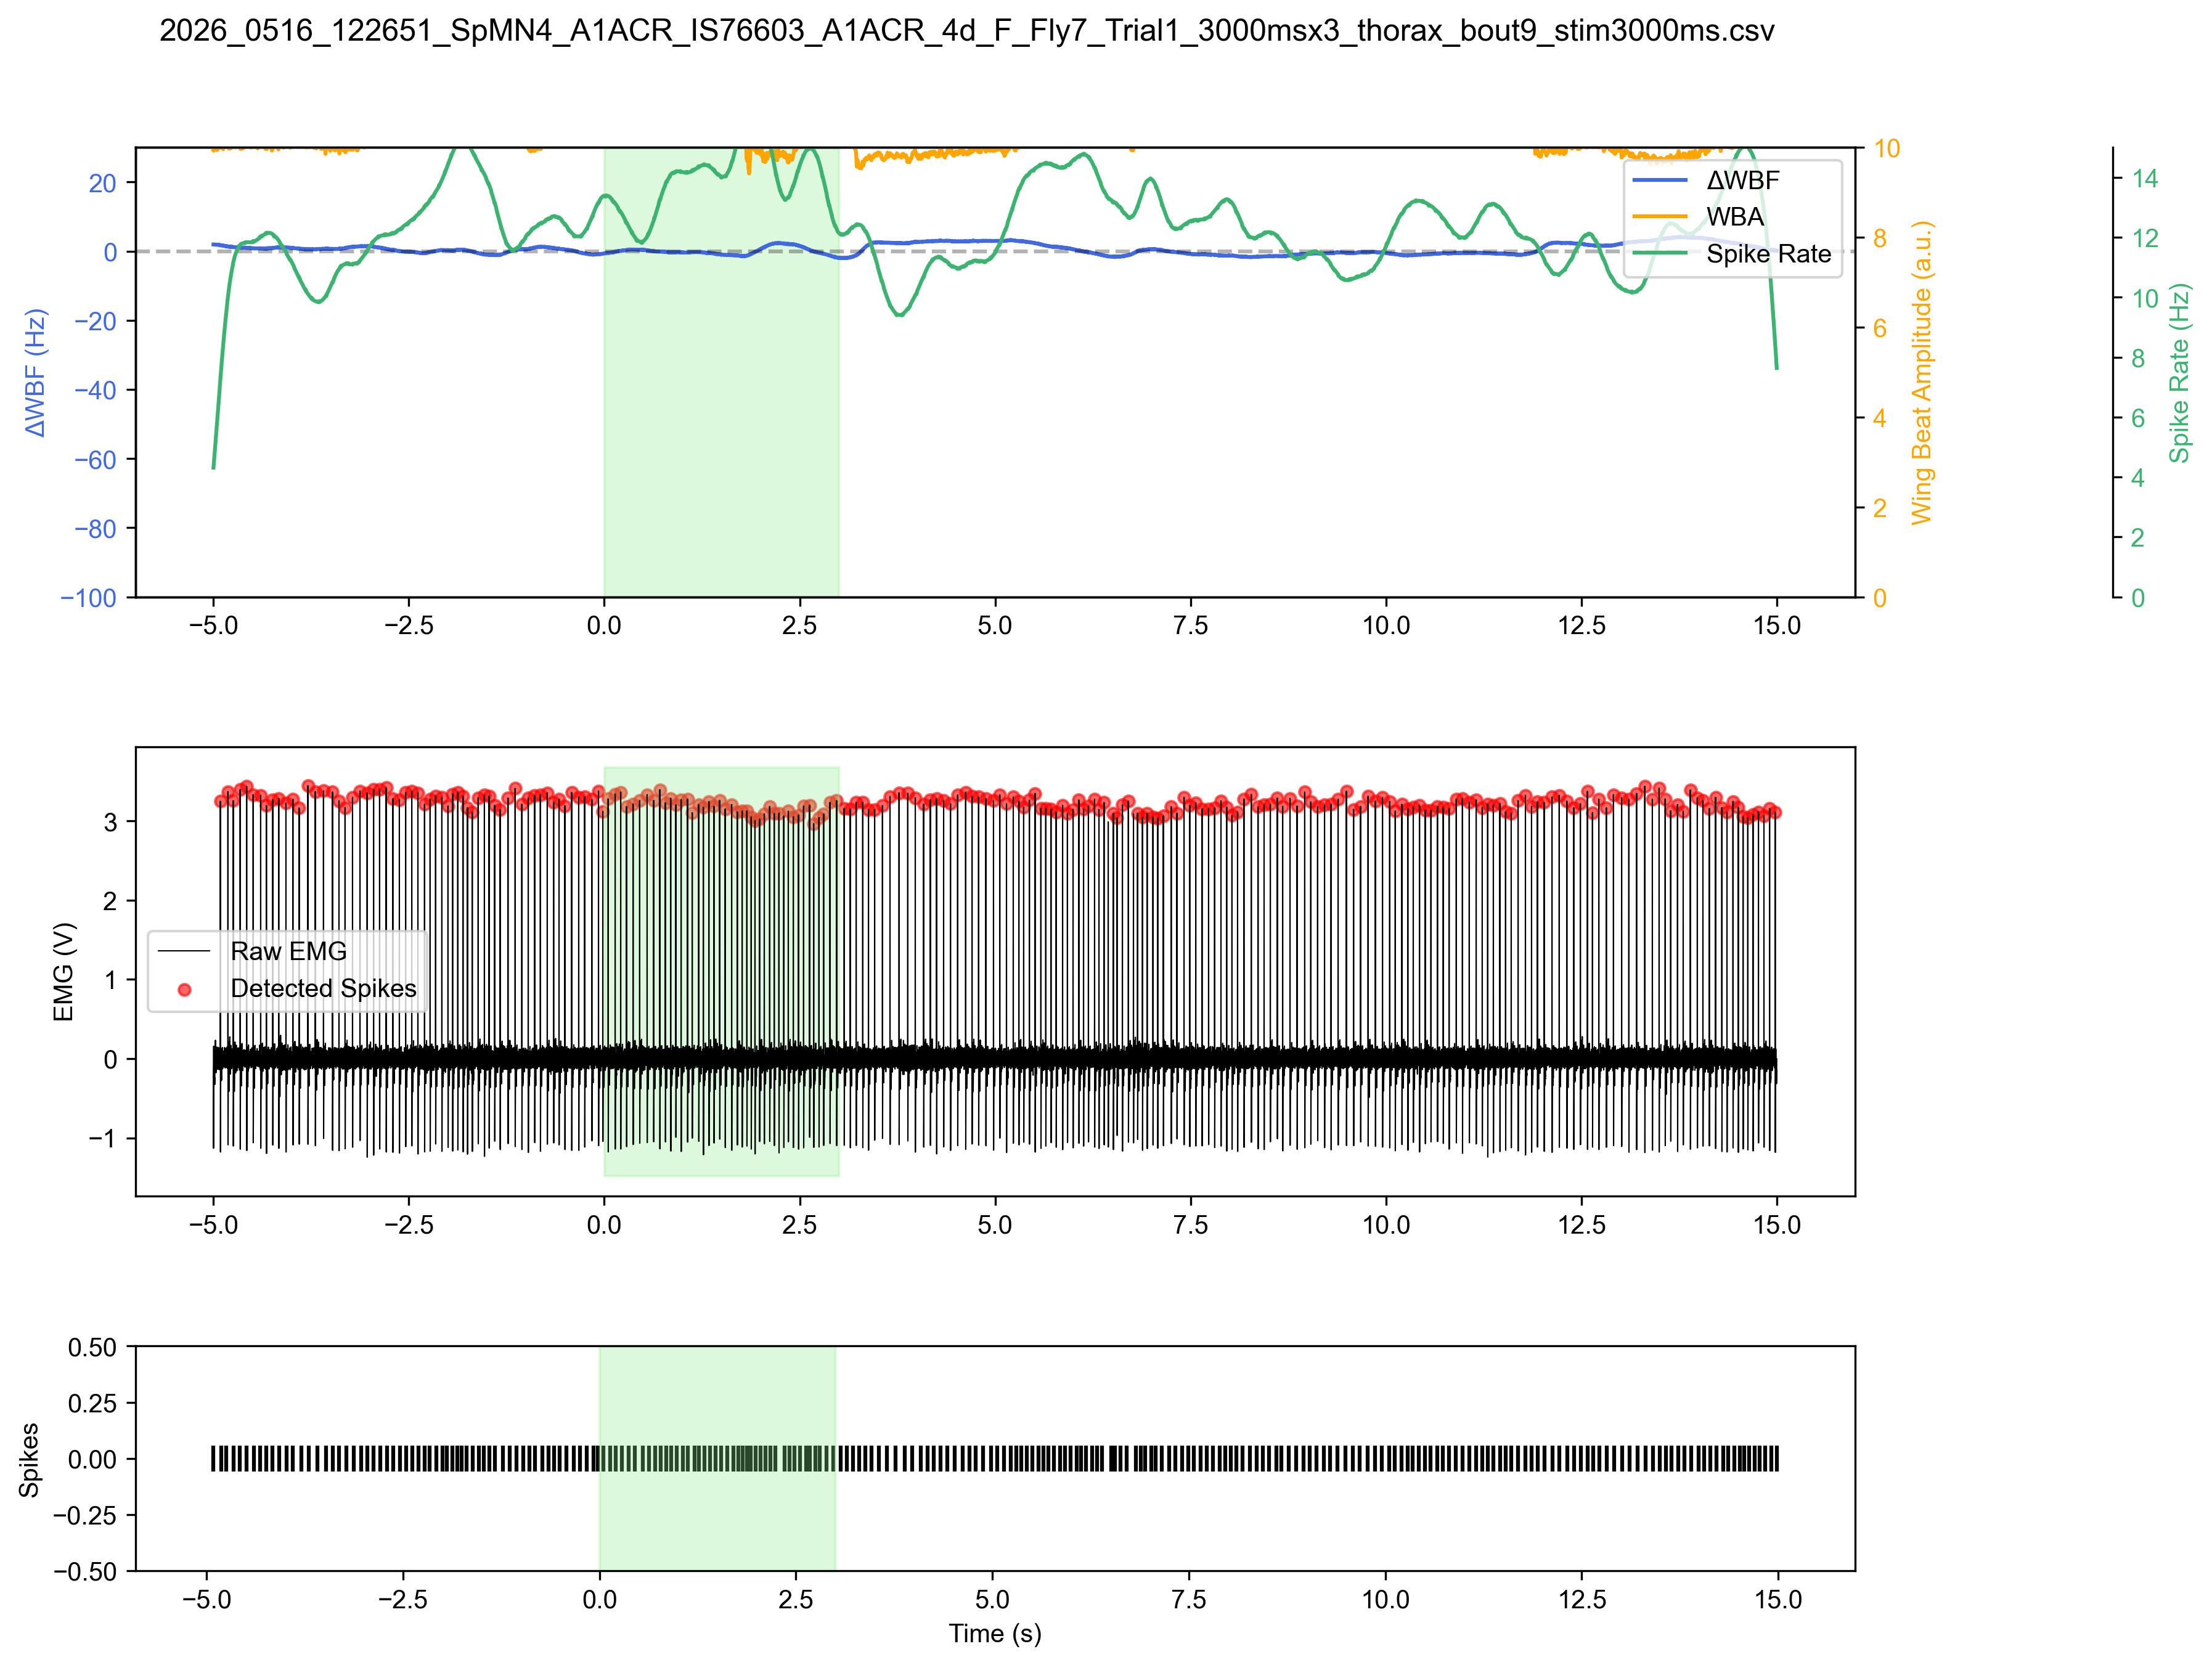

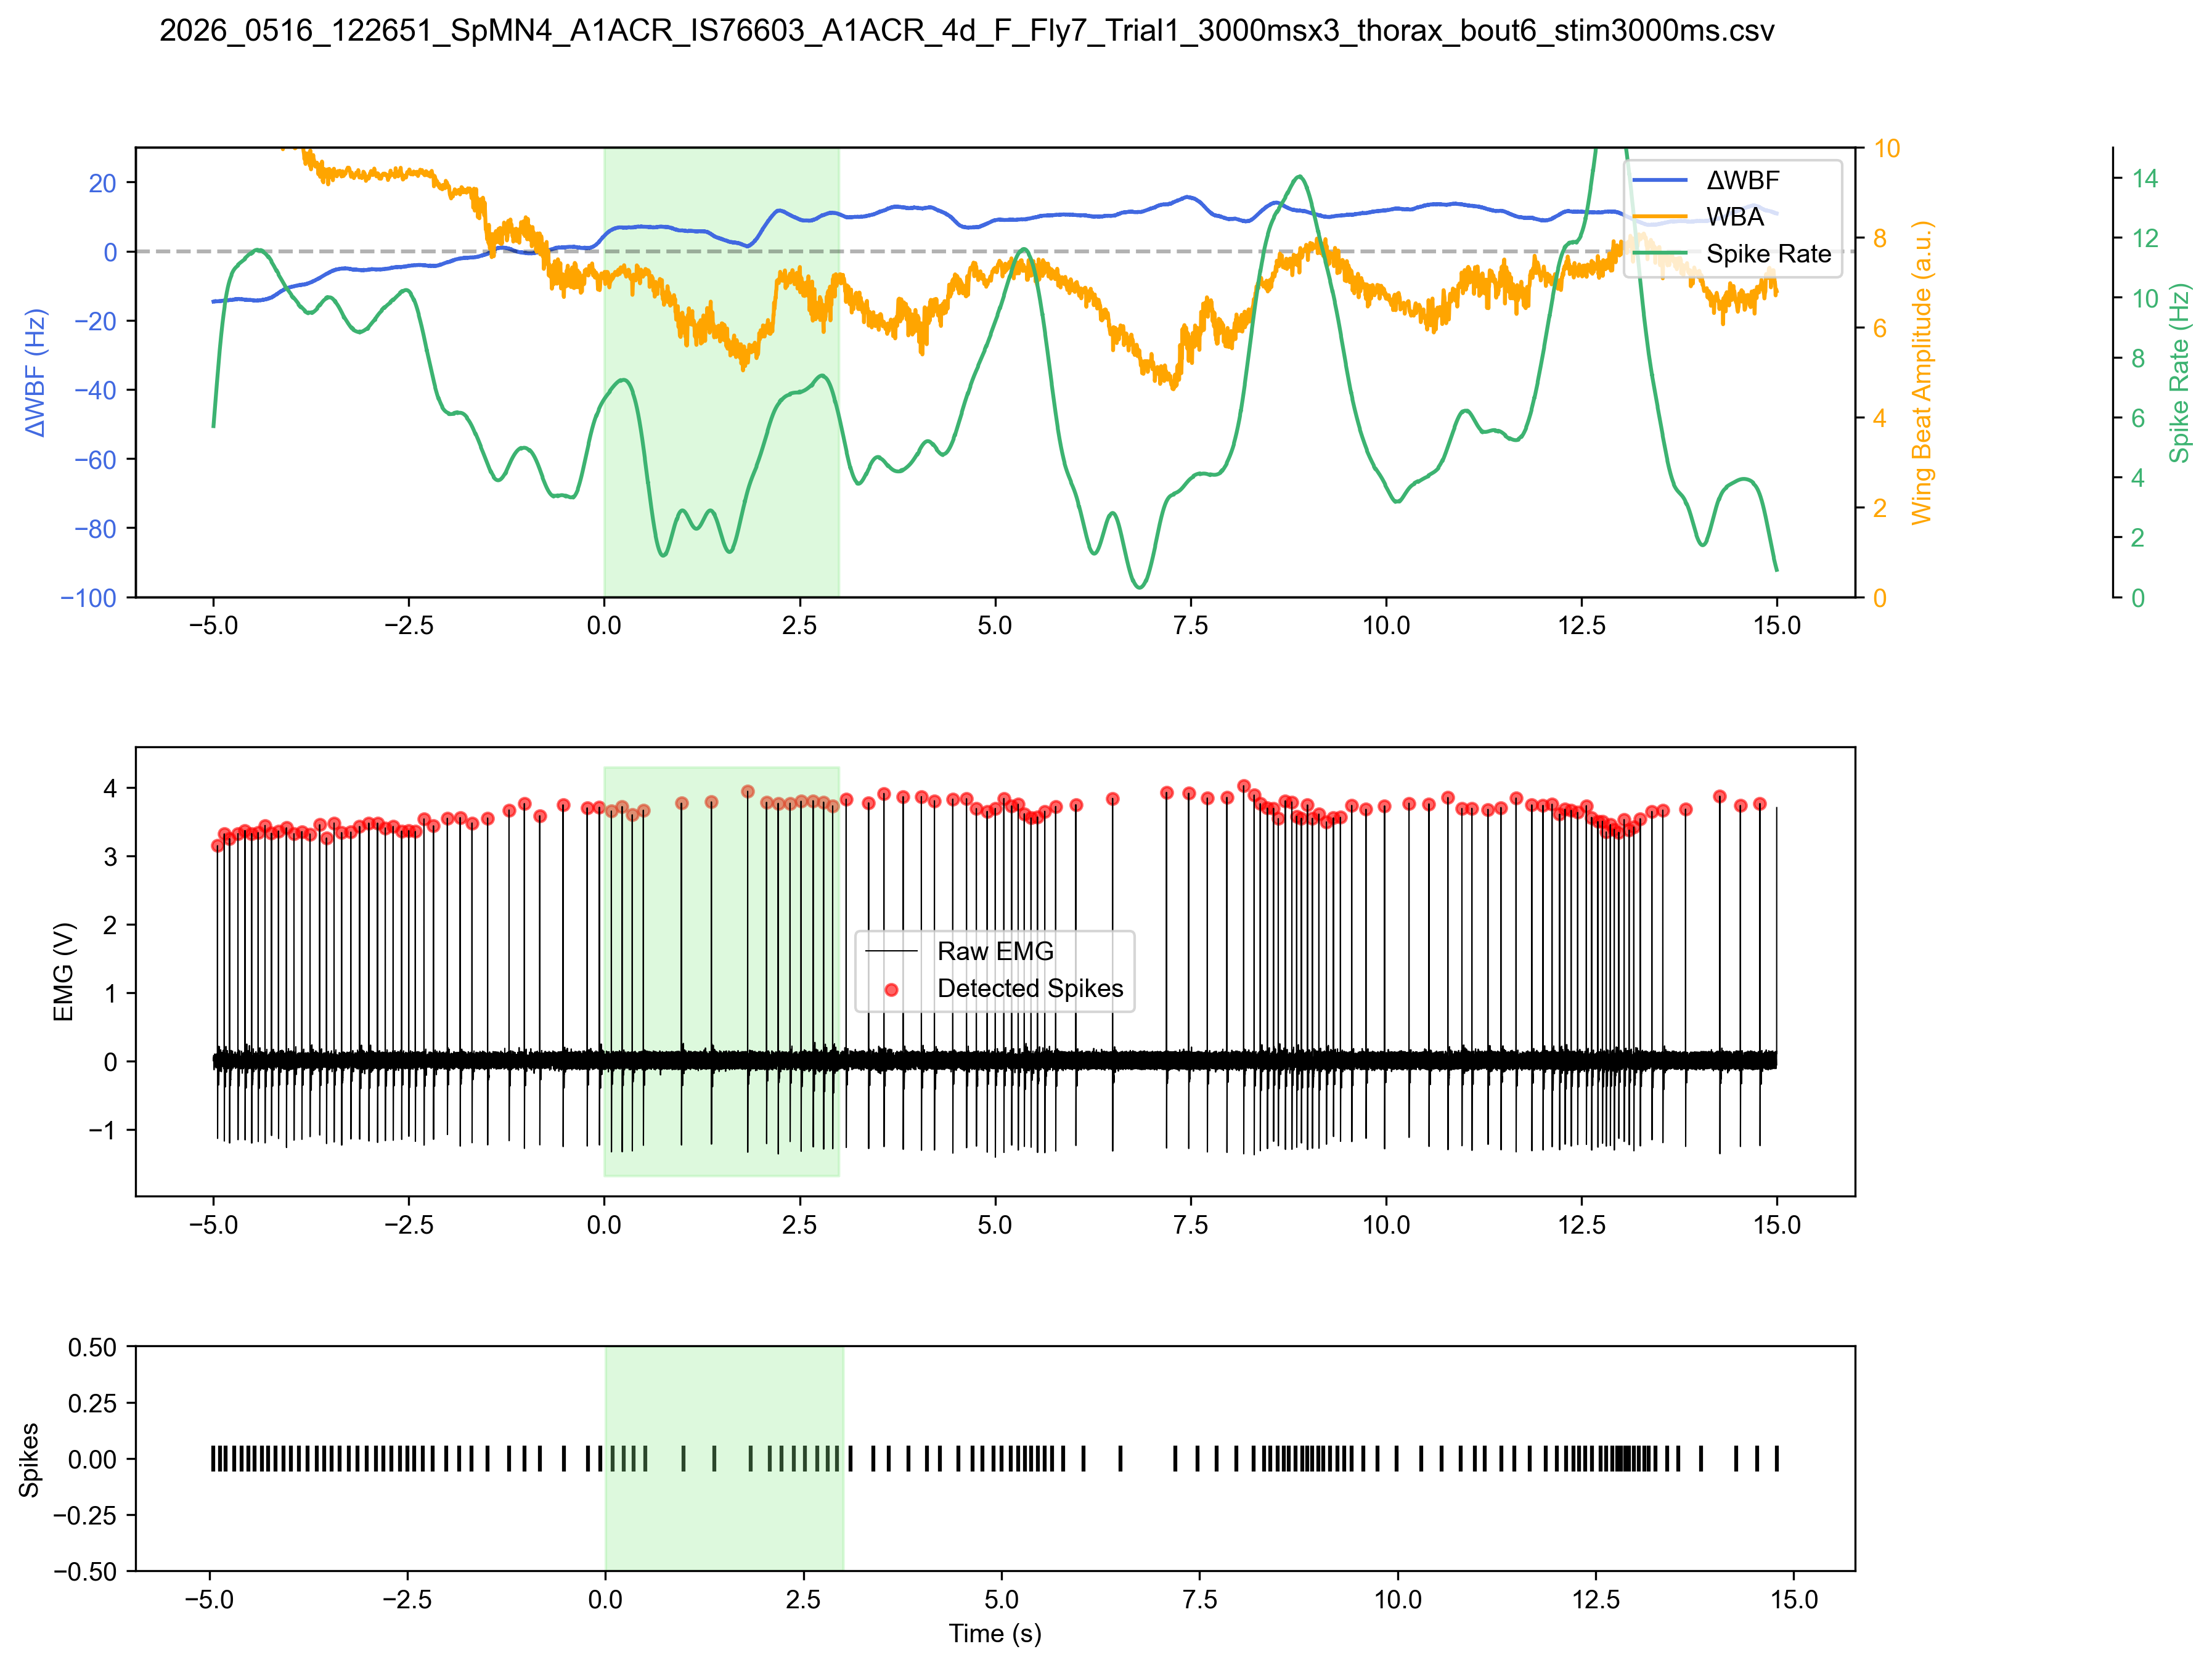

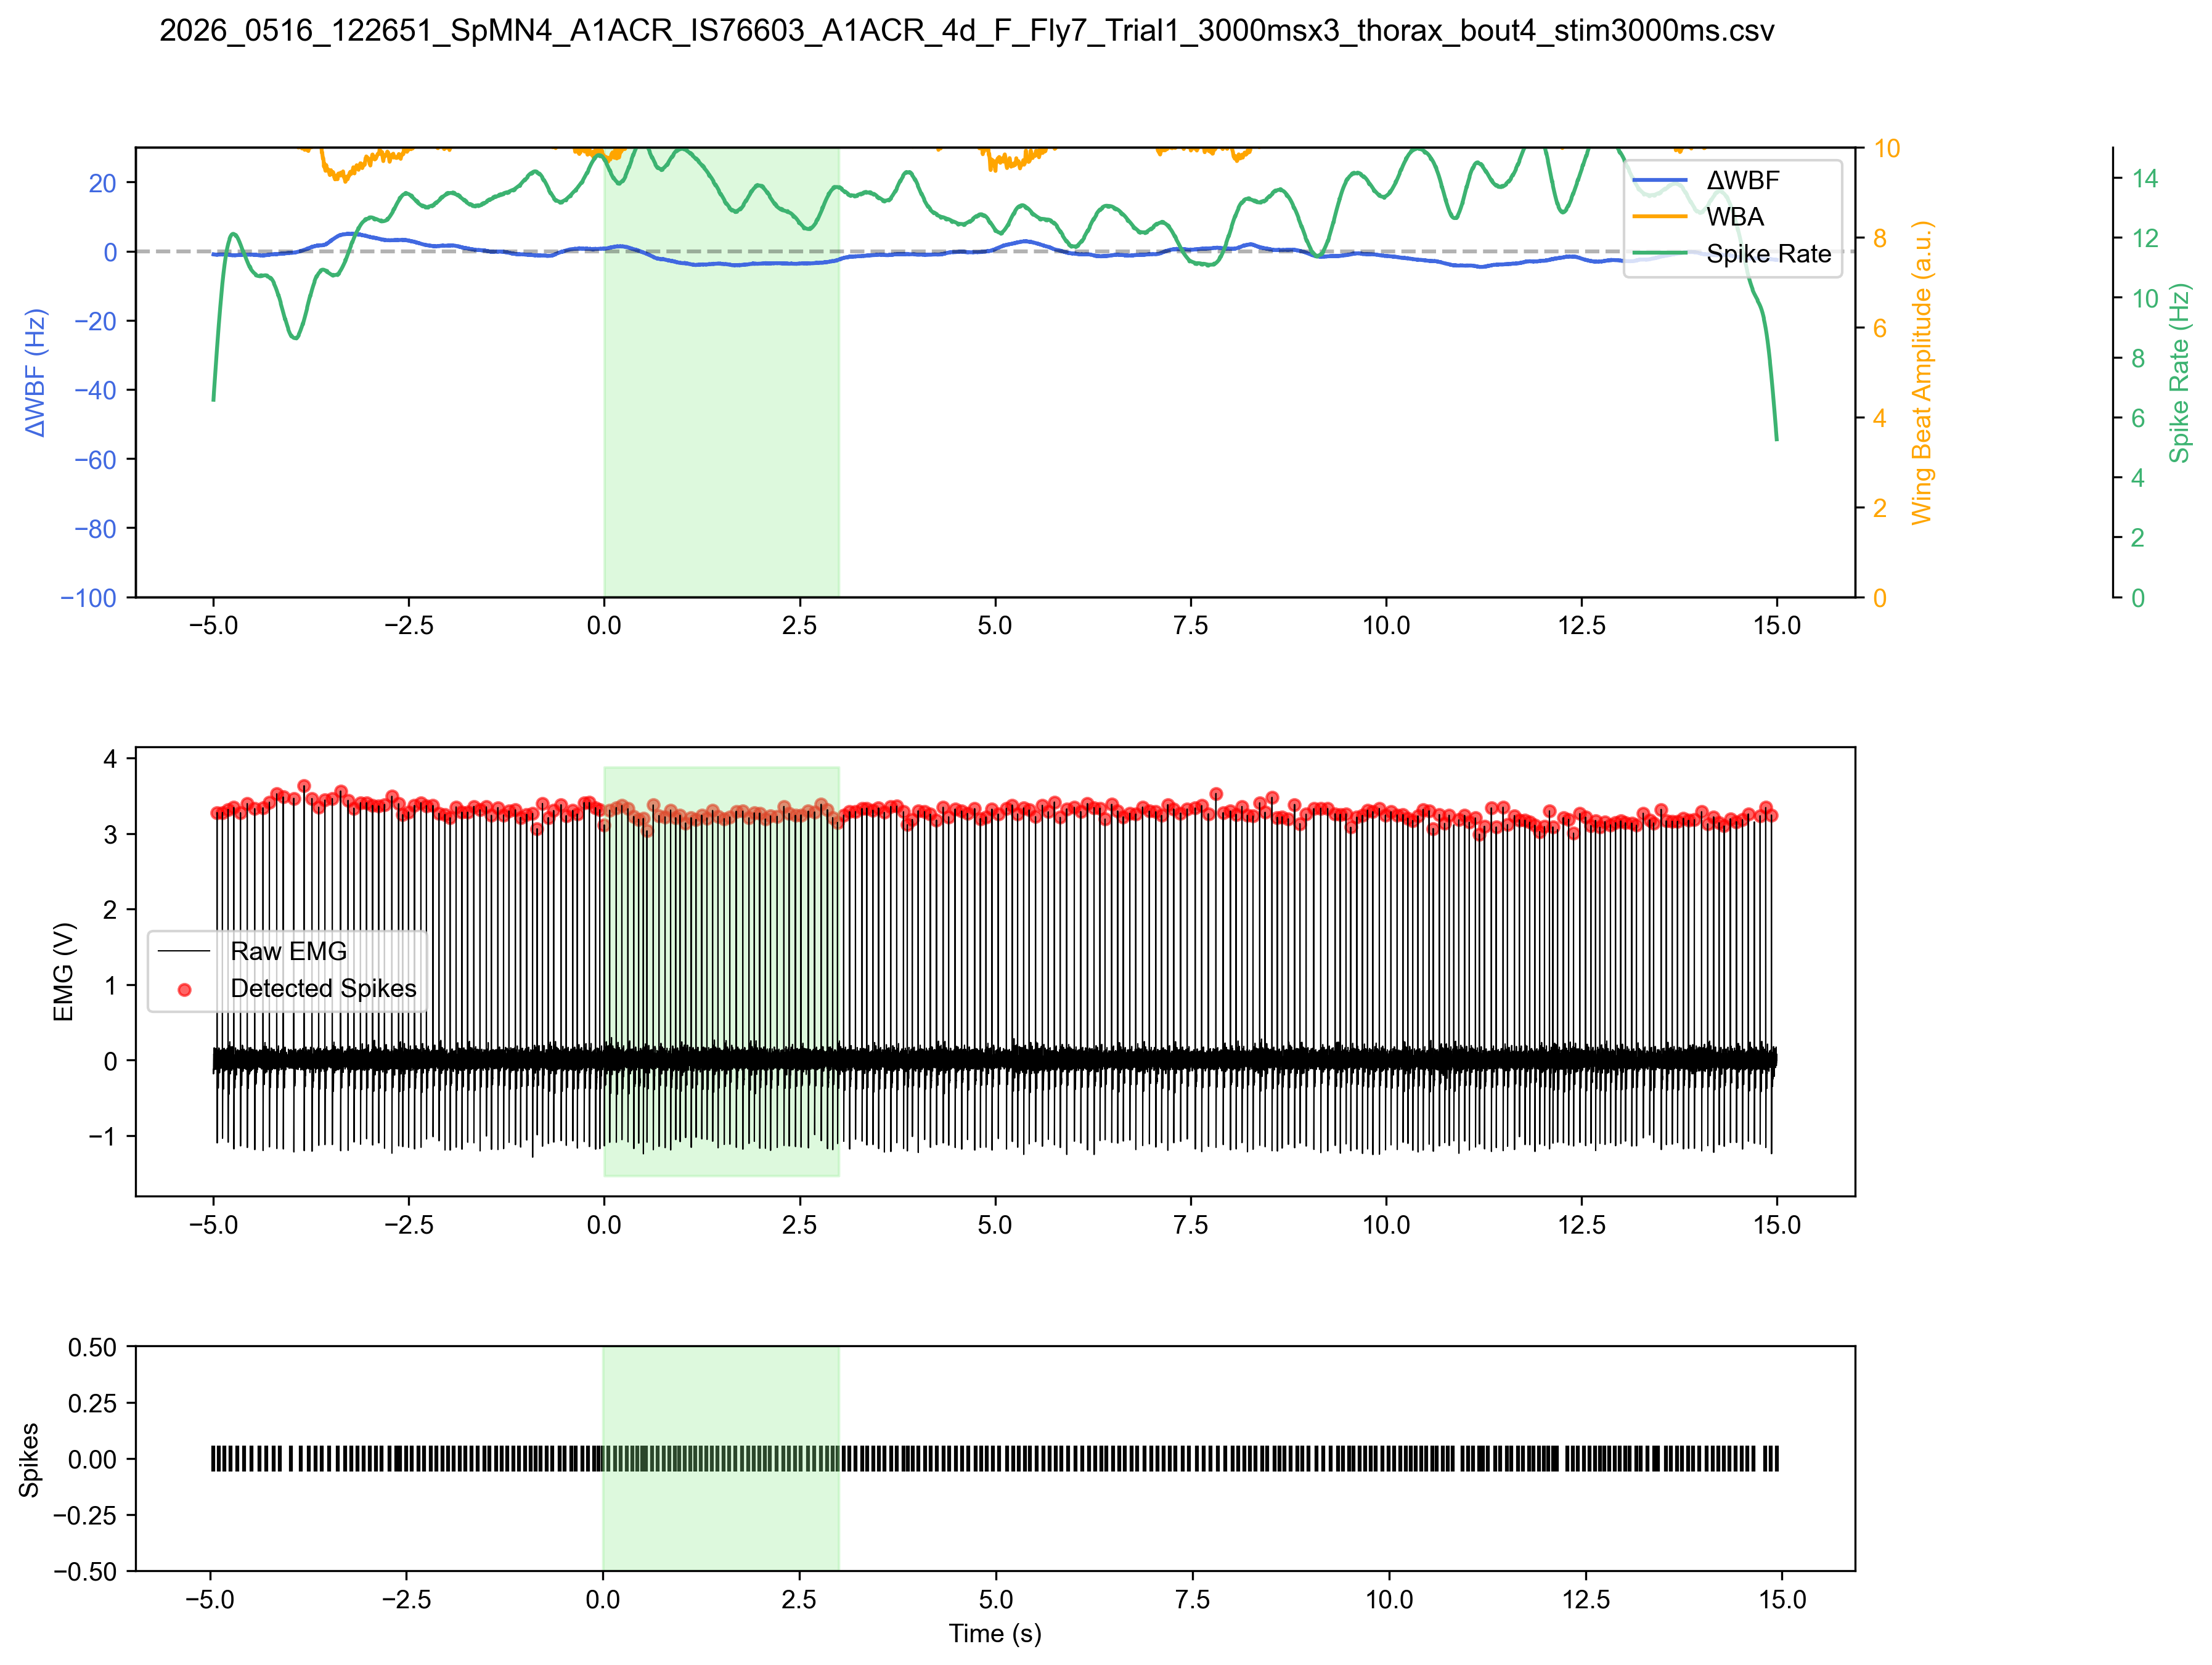

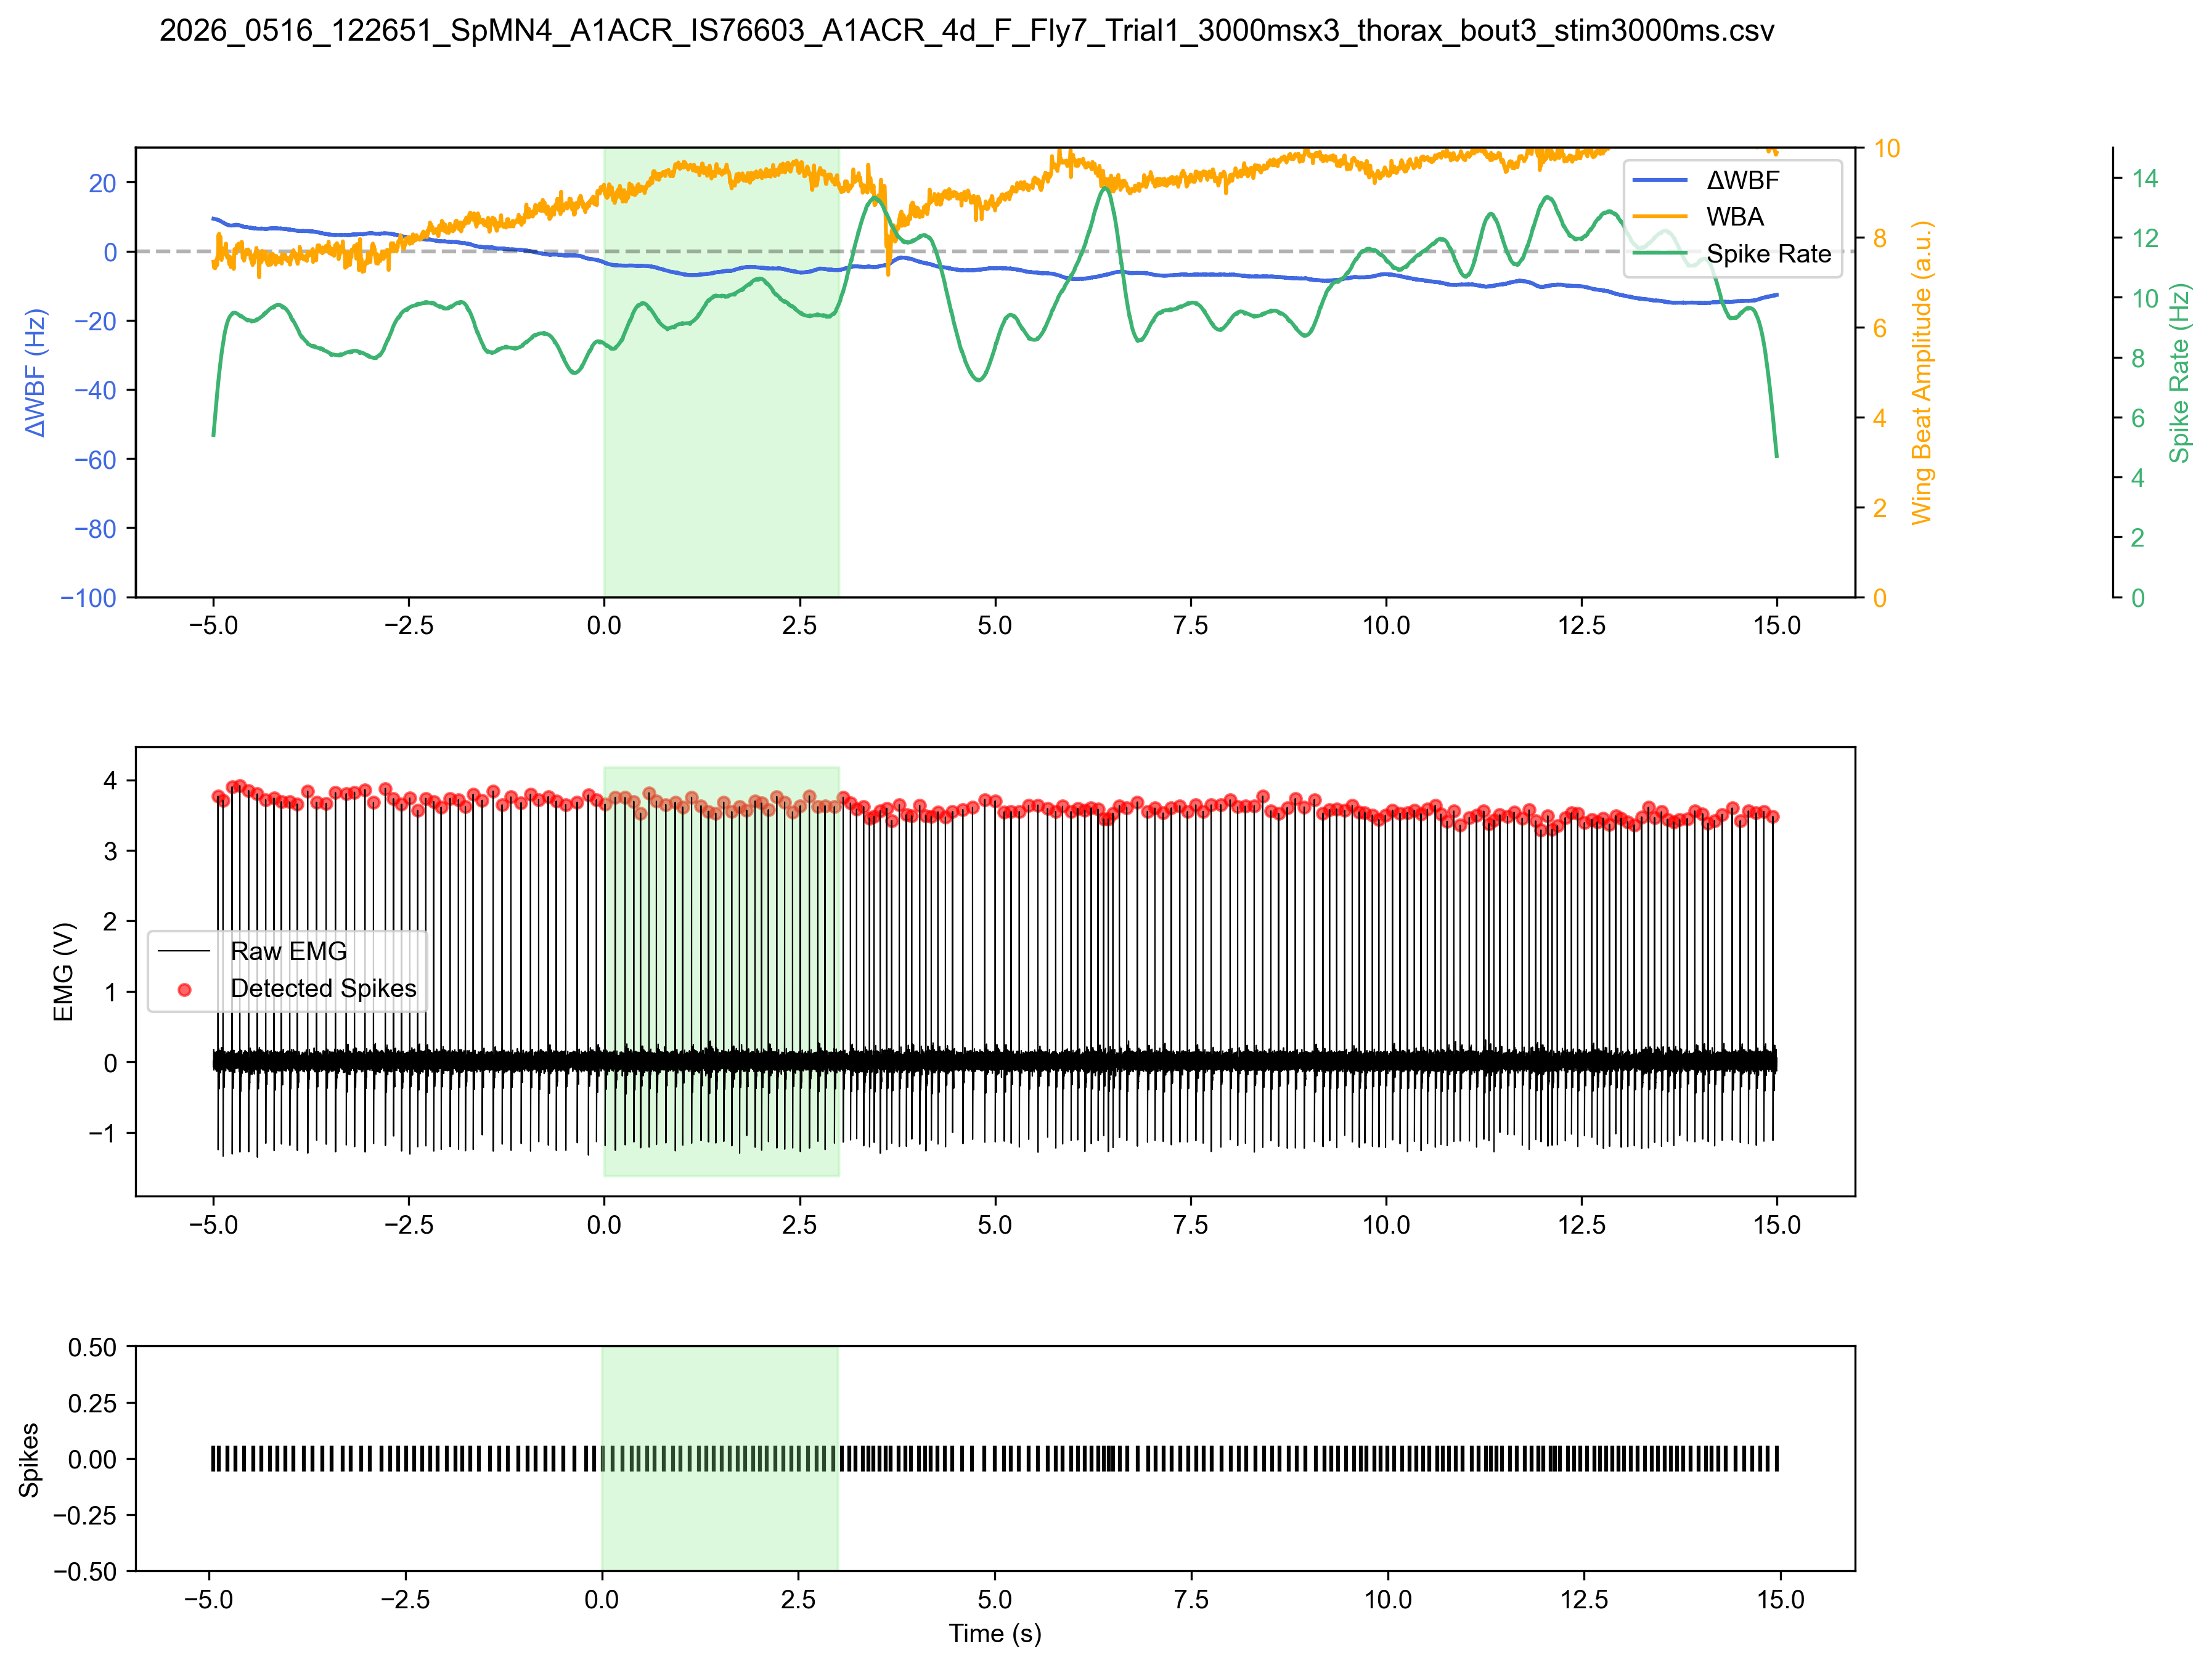

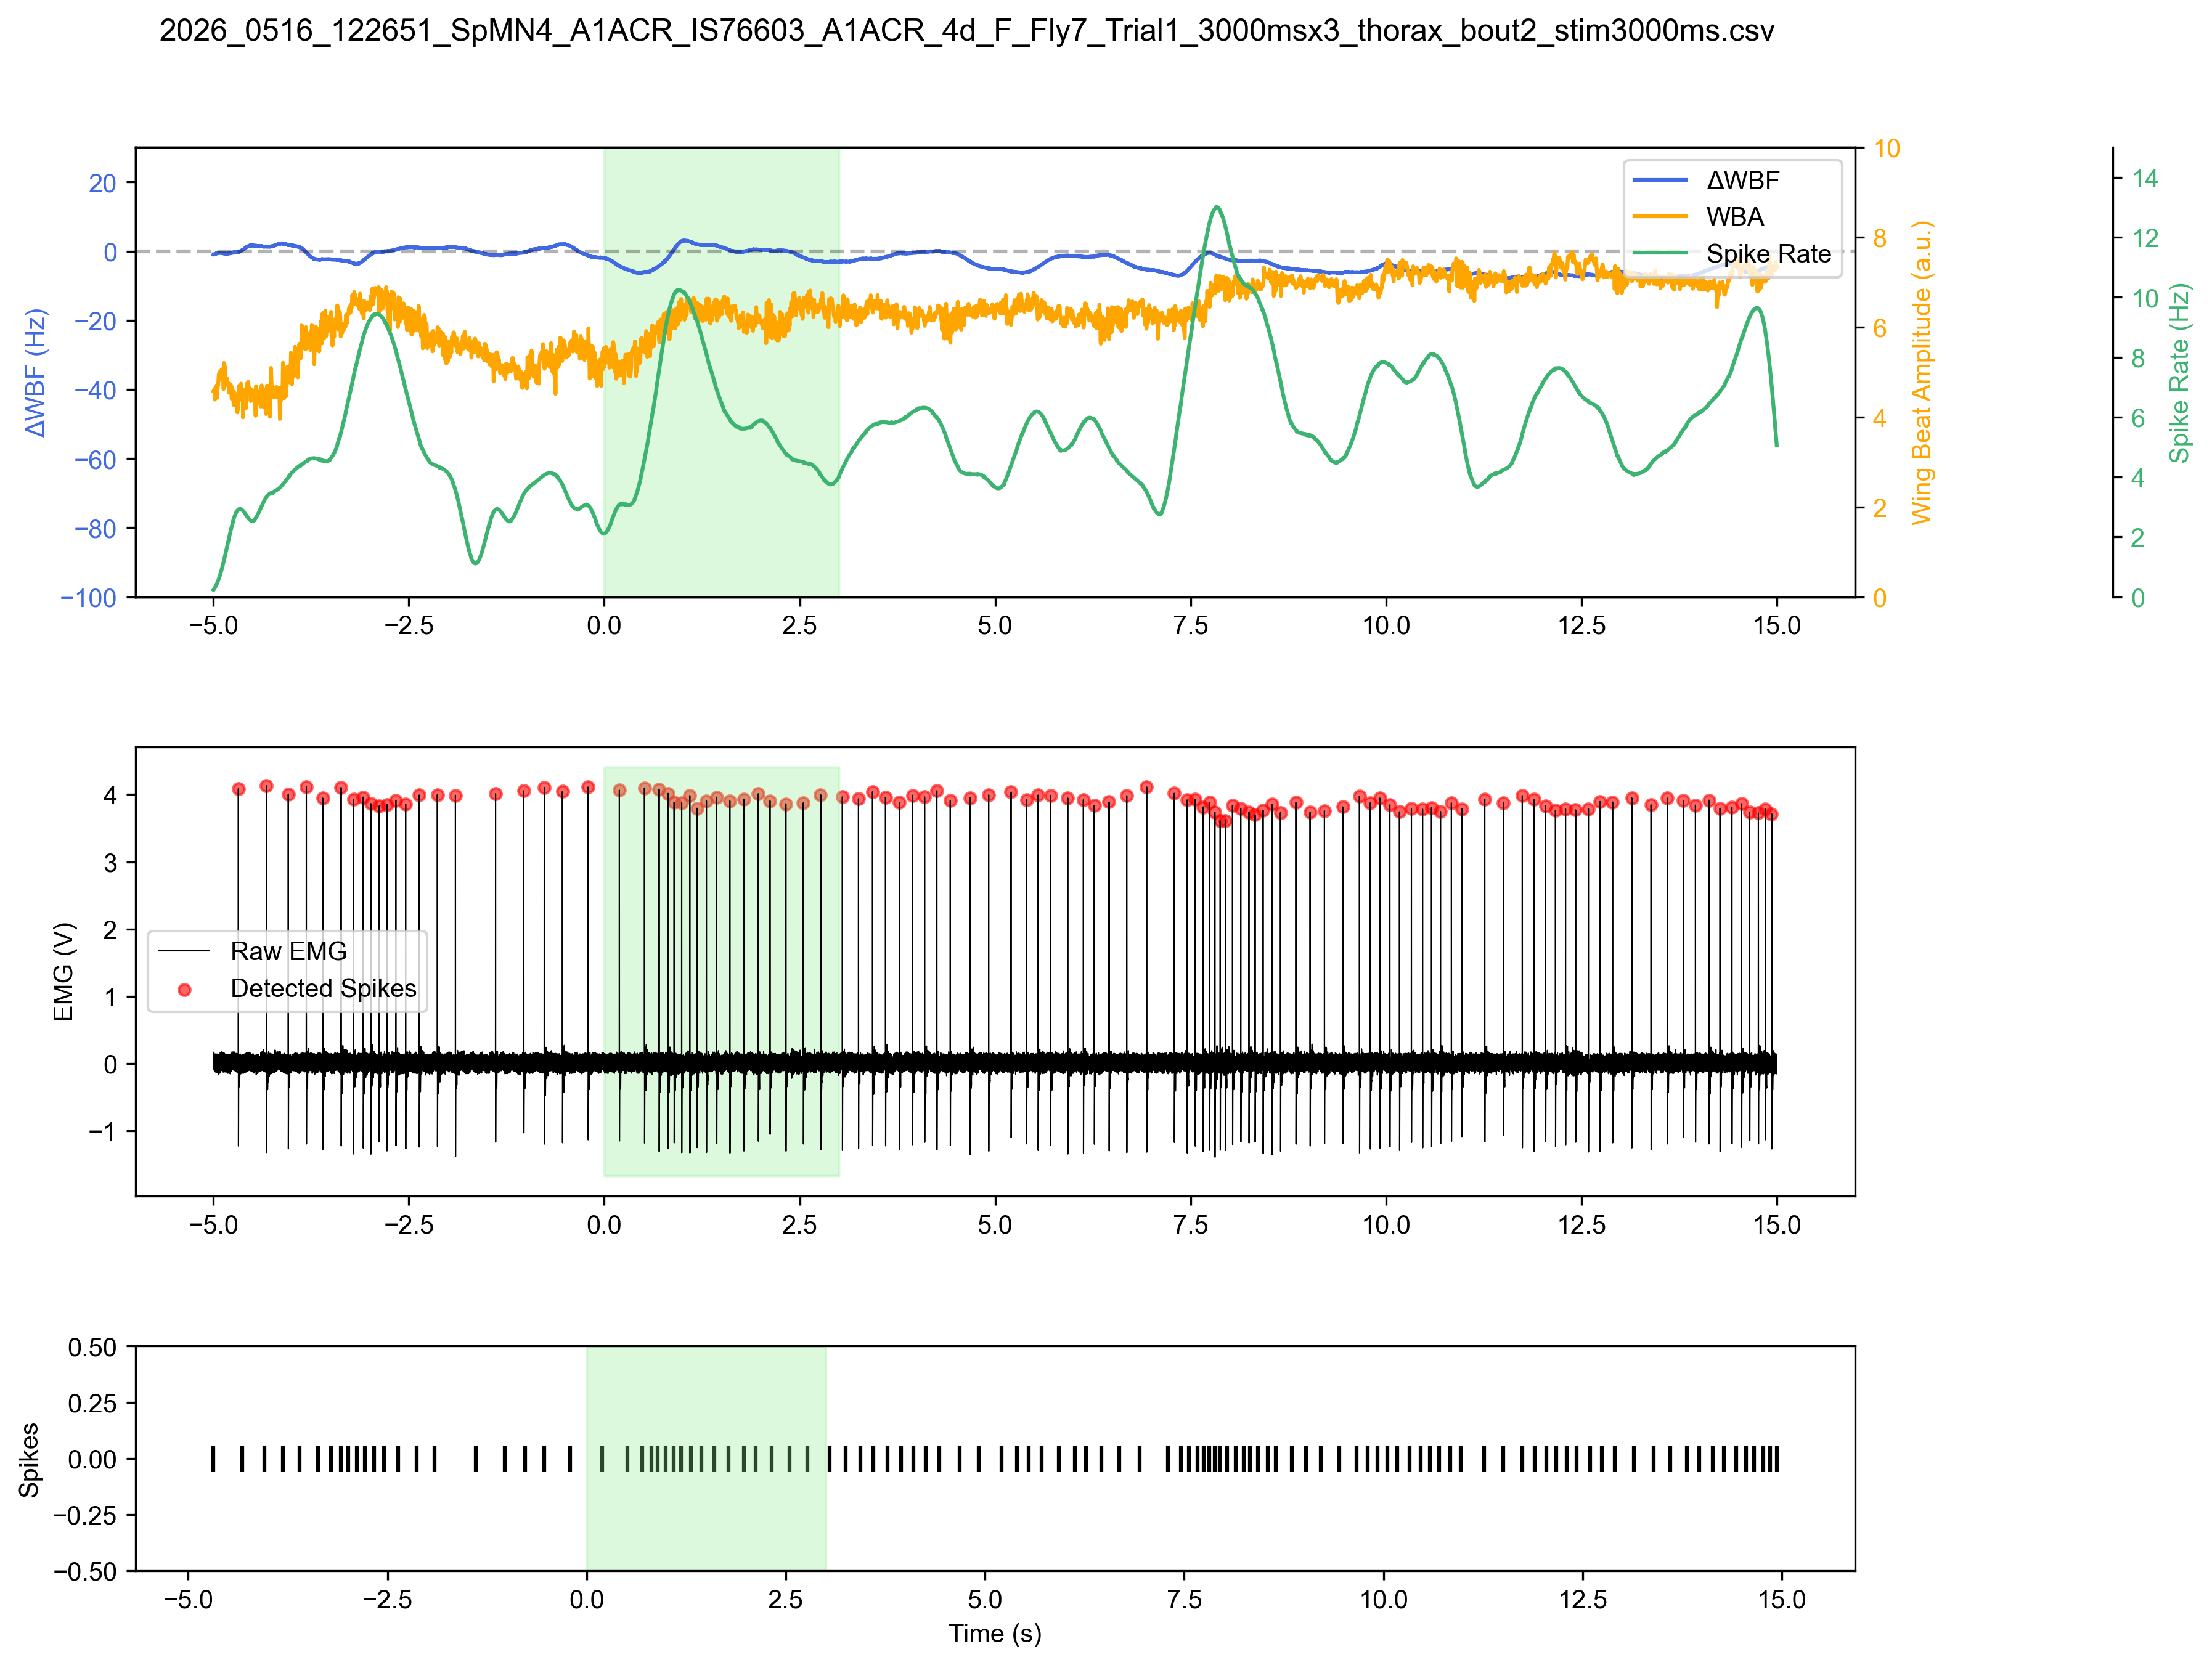

In [23]:
# Step 3, check the quality of filtered spikes. Will need to remove certain bouts manually afterwards.

import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'
set_plot_style()

def plot_filtered_data():
    """
    Plots the filtered spike data for quality check.
    
    This function iterates through subdirectories in the filtered data directory,
    creates plot subdirectories, and generates plots for each CSV file using plot_single_bout.
    """
    # Get filtered data directory. This is usually the "output_csv_spikefiltered" folder.
    filtered_dir = Path('/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/8_SpMN4_A1ACR/260516_SpMN4_A1ACR_EMG_Fly7/output_csv_spikefiltered')
    
    # Create output directory for plots
    plot_dir = filtered_dir / 'output_plots'
    plot_dir.mkdir(exist_ok=True)
    
    # Process each subdirectory (different stim times)
    for stim_dir in filtered_dir.iterdir():
        if stim_dir.is_dir():
            plot_subdir = plot_dir / stim_dir.name
            plot_subdir.mkdir(exist_ok=True)
            
            # Plot each CSV file
            for csv_file in stim_dir.glob('*.csv'):
                plot_single_bout(str(csv_file), output_dir=str(plot_subdir))

if __name__ == "__main__":
    plot_filtered_data()

**Bout quality summary table.** Builds one row per filtered bout CSV with the key statistics for deciding which to keep: stimulus duration, baseline vs stimulus mean WBF (and their delta), baseline vs stimulus WBA, baseline vs stimulus spike rate, spike counts, and an empty `keep` column to fill in manually. Saved as `bout_quality_summary.csv`.

**片段质量汇总表。** 为每个筛选后的片段 CSV 生成一行，包含决定取舍所需的关键统计量：刺激时长、基线对刺激的平均 WBF（及其差值）、基线对刺激的 WBA、基线对刺激的发放率、锋电位计数，以及一个供人工填写的空 `keep` 列。保存为 `bout_quality_summary.csv`。

In [24]:
# Save data summary CSV for Block 3 quality check.
# Rows = one per bout CSV; columns = key stats for deciding which bouts to keep.

import pandas as pd
import numpy as np
import os
import re
from pathlib import Path

# ====== EDIT THIS ======
filtered_dir = Path('/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/8_SpMN4_A1ACR/260516_SpMN4_A1ACR_EMG_Fly7/output_csv_spikefiltered')
# =======================

BASELINE_START = -2.0   # seconds relative to stim onset
BASELINE_END   =  0.0
DEFAULT_STIM_WIN = 3.0  # seconds; used when stim_duration == 0 ms

def _summarize_bout(csv_path: str) -> dict:
    df = pd.read_csv(csv_path)
    fname = os.path.basename(csv_path)

    m = re.search(r'stim(\d+)ms', fname)
    stim_ms = int(m.group(1)) if m else 0
    stim_end_s = stim_ms / 1000.0 if stim_ms > 0 else DEFAULT_STIM_WIN

    bl_mask   = (df['Time (s)'] >= BASELINE_START) & (df['Time (s)'] < BASELINE_END)
    stim_mask = (df['Time (s)'] >= 0)              & (df['Time (s)'] < stim_end_s)

    def col_mean(col, mask):
        return float(df.loc[mask, col].mean()) if col in df.columns else np.nan

    def col_sum(col, mask):
        return int(df.loc[mask, col].sum()) if col in df.columns else np.nan

    bl_wbf = col_mean('Wingbeat Frequency', bl_mask)
    st_wbf = col_mean('Wingbeat Frequency', stim_mask)
    delta  = (st_wbf - bl_wbf) if np.isfinite(bl_wbf) and np.isfinite(st_wbf) else np.nan

    return {
        'filename':             fname,
        'stim_duration_ms':     stim_ms,
        'baseline_WBF':         round(bl_wbf, 2) if np.isfinite(bl_wbf) else np.nan,
        'stim_WBF':             round(st_wbf, 2) if np.isfinite(st_wbf) else np.nan,
        'delta_WBF':            round(delta,  2) if np.isfinite(delta)  else np.nan,
        'baseline_WBA':         round(col_mean('Wing Beat Amplitude', bl_mask),   3),
        'stim_WBA':             round(col_mean('Wing Beat Amplitude', stim_mask), 3),
        'baseline_spike_rate':  round(col_mean('Spike Rate', bl_mask),   3),
        'stim_spike_rate':      round(col_mean('Spike Rate', stim_mask), 3),
        'n_spikes_baseline':    col_sum('Spike Count', bl_mask),
        'n_spikes_stim':        col_sum('Spike Count', stim_mask),
        'keep':                 '',   # fill in manually: 'Y' to keep, 'N' to exclude
    }

rows = []
for stim_subdir in sorted(filtered_dir.iterdir()):
    if stim_subdir.is_dir():
        for csv_file in sorted(stim_subdir.glob('*.csv')):
            try:
                rows.append(_summarize_bout(str(csv_file)))
            except Exception as e:
                print(f"Skipping {csv_file.name}: {e}")

if rows:
    COL_ORDER = [
        'filename', 'stim_duration_ms',
        'baseline_WBF', 'stim_WBF', 'delta_WBF',
        'baseline_WBA', 'stim_WBA',
        'baseline_spike_rate', 'stim_spike_rate',
        'n_spikes_baseline', 'n_spikes_stim',
        'keep',
    ]
    summary_df = pd.DataFrame(rows, columns=COL_ORDER)
    out_path = filtered_dir / 'bout_quality_summary.csv'
    summary_df.to_csv(out_path, index=False)
    print(f"Saved quality summary ({len(summary_df)} bouts) →\n  {out_path}")
    display(summary_df)
else:
    print("No CSV files found in", filtered_dir)


Saved quality summary (9 bouts) →
  /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/8_SpMN4_A1ACR/260516_SpMN4_A1ACR_EMG_Fly7/output_csv_spikefiltered/bout_quality_summary.csv


,filename,stim_duration_ms,baseline_WBF,stim_WBF,delta_WBF,baseline_WBA,stim_WBA,baseline_spike_rate,stim_spike_rate,n_spikes_baseline,n_spikes_stim,keep
0,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,0,228.19,229.79,1.60,6.418,6.265,5.855,5.604,12,17,
1,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,0,209.34,209.48,0.15,10.338,10.305,13.070,13.105,26,40,
2,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,0,230.85,227.76,-3.09,7.684,7.861,10.384,7.604,21,22,
3,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,3000,234.44,233.15,-1.29,5.335,6.099,2.969,5.782,6,17,
4,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,3000,222.74,217.41,-5.33,8.517,9.353,8.537,9.576,17,29,
5,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,3000,208.99,206.34,-2.64,10.170,10.393,13.628,13.756,28,41,
6,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,3000,221.66,228.49,6.83,7.917,6.474,4.685,4.646,9,14,
7,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,3000,211.82,213.69,1.87,10.172,10.104,13.019,12.515,26,38,
8,2026_0516_122651_SpMN4_A1ACR_IS76603_A1ACR_4d_...,3000,213.29,213.29,-0.00,10.229,10.187,13.012,14.024,27,42,
